[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/danpele/MFM/blob/main/notebooks/EN/chapter16_lecture_notebook.ipynb)

# Modelling Financial Markets — Chapter 16: Digital Assets and DeFi

*Lecture notebook. Daniel Traian Pele, Bucharest University of Economic Studies.*

This notebook reproduces every chart and table of Lecture 16: the crypto market, stylised facts, a CRIX-style index, stablecoins, automated market makers, spot ETFs, crypto equities and the asset-class map.

> **Working in Google Colab? Save your own copy first.**
> The Colab link opens a temporary copy: when you close the tab or the session times out, your changes are lost.
> Use **File → Save a copy in Drive** (it goes to the *Colab Notebooks* folder of your ASE Google Drive) and work in that copy.
> For the team project, **File → Save a copy in GitHub** puts the notebook directly in your team's repository.
> Files you create while the notebook runs (CSV, charts) are also temporary: set `SAVE_TO_DRIVE = True` in the next cell to keep them.

In [ ]:
# Optional (Colab only): keep the files you create in Google Drive
SAVE_TO_DRIVE = False   # set to True, run this cell and allow access to your Drive

import os
OUT_DIR = '.'
if SAVE_TO_DRIVE:
    from google.colab import drive
    drive.mount('/content/drive')
    OUT_DIR = '/content/drive/MyDrive/MFM/Chapter_16'
    os.makedirs(OUT_DIR, exist_ok=True)
print('Save your outputs to:', os.path.abspath(OUT_DIR))


In [1]:
import os
import json
import time
import urllib.request
import urllib.parse
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from scipy import stats
from scipy.signal import lfilter
import statsmodels.api as sm
import warnings
warnings.filterwarnings('ignore')

## Style and helpers

In [2]:
# Stil standard MFM (identic cu SFM): transparent + ENG + legenda jos
plt.rcParams['figure.facecolor'] = 'none'
plt.rcParams['axes.facecolor'] = 'none'
plt.rcParams['savefig.facecolor'] = 'none'
plt.rcParams['savefig.transparent'] = True
plt.rcParams['axes.grid'] = False
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Helvetica', 'Arial', 'DejaVu Sans']
plt.rcParams['font.size'] = 9
plt.rcParams['axes.labelsize'] = 10
plt.rcParams['axes.titlesize'] = 11
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.linewidth'] = 0.6
plt.rcParams['lines.linewidth'] = 1.1
plt.rcParams['legend.facecolor'] = 'none'
plt.rcParams['legend.framealpha'] = 0
plt.rcParams['legend.fontsize'] = 8

# Culori brand (gri doar pentru linii de referinta si grila)
MainBlue = '#1A3A6E'
IDAred   = '#CD0000'
Forest   = '#2E7D32'
Amber    = '#B5853F'
Orange   = '#E67E22'
Purple   = '#8E44AD'
Crimson  = '#DC3545'
Teal     = '#17A2B8'
Magenta  = '#D63384'
Brown    = '#795548'
Gray     = '#7F7F7F'
COL = {'BTC': Orange, 'ETH': Purple, 'XRP': MainBlue, 'ADA': Forest, 'DOGE': Amber, 'LTC': Teal, 'LINK': IDAred,
       'SOL': Magenta, 'BNB': Brown, 'SPX': MainBlue, 'GOLD': Amber, 'QQQ': Teal, 'USDT': Forest, 'USDC': MainBlue,
       'DAI': Orange, 'IBIT': MainBlue, 'ETHA': Purple, 'COIN': MainBlue, 'MSTR': IDAred, 'TLT': Forest}
CLASS_COL = {'Crypto': Orange, 'Equity': MainBlue, 'FX': Forest, 'Commodity': Amber, 'Bond': Purple}

HERE = '.'
SEED = 42
ETF_START = '2024-01-11'
B_BOOT = 2000


def save_fig(name):
    """Salveaza figura ca PDF si PNG transparent, in folderul curent."""
    plt.savefig(f'{name}.pdf', bbox_inches='tight', transparent=True)
    plt.savefig(f'{name}.png', bbox_inches='tight', transparent=True, dpi=180)
    plt.show()
    plt.close()
    print(f"   saved {name}")


def legend_outside_bottom(ax, ncol=2, y=-0.22):
    """Plaseaza legenda in afara graficului, jos-centru."""
    ax.legend(loc='upper center', bbox_to_anchor=(0.5, y), ncol=ncol, frameon=False)


def fig_legend_bottom(fig, handles=None, labels=None, ncol=4, y=0.0):
    """O singura legenda sub o figura cu mai multe panouri."""
    if handles is None:
        handles, labels = [], []
        for ax in fig.axes:
            for h, l in zip(*ax.get_legend_handles_labels()):
                if l not in labels and not l.startswith('_'):
                    handles.append(h)
                    labels.append(l)
    fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, y), ncol=ncol, frameon=False)


def jsonable(x):
    """Converteste recursiv numerele numpy si datele in tipuri JSON."""
    if isinstance(x, dict):
        return {str(k): jsonable(v) for k, v in x.items()}
    if isinstance(x, (list, tuple)):
        return [jsonable(v) for v in x]
    if isinstance(x, (np.floating, float)):
        return None if not np.isfinite(x) else float(x)
    if isinstance(x, (np.integer,)):
        return int(x)
    if isinstance(x, (pd.Timestamp,)):
        return str(x.date())
    return x


def max_drawdown(p):
    """Cea mai mare scadere de la un maxim anterior (in %) si data minimului."""
    dd = p / p.cummax() - 1
    return 100 * dd.min(), dd.idxmin()


def hill(x, frac=0.05):
    """Estimatorul Hill al indicelui de coada pentru cele mai mari frac din valorile pozitive ale lui x."""
    x = np.sort(x[x > 0])[::-1]
    k = max(int(frac * len(x)), 10)
    return 1 / np.mean(np.log(x[:k] / x[k]))


def hac_ols(y, X, lags=4):
    """Regresie OLS cu erori standard Newey-West (HAC)."""
    return sm.OLS(y, sm.add_constant(X)).fit(cov_type='HAC', cov_kwds={'maxlags': lags})


import tempfile
# SAVE_TO_DRIVE = True (Colab cell above): charts and tables go to OUT_DIR in Google Drive; otherwise tables go to a temporary folder
KEEP = bool(globals().get('SAVE_TO_DRIVE', False))
HERE = globals().get('OUT_DIR', '.') if KEEP else tempfile.gettempdir()


def save_fig(name):
    """Show the figure; with SAVE_TO_DRIVE, also save it as PNG in OUT_DIR."""
    if KEEP:
        plt.savefig(os.path.join(HERE, f'{name}.png'), bbox_inches='tight', transparent=True, dpi=180)
    plt.show()
    plt.close()

## Data

- Daily closes up to 18 September 2026: crypto-assets 7 days a week; ETFs and shares on weekdays, adjusted for dividends and splits.
- Coins in circulation: Coin Metrics Community Data; DeFi total value locked and stablecoin supply: DefiLlama.
- Joint analyses use common days: prices are joined first, then returns are computed.

In [3]:
REPO_RAW = 'https://raw.githubusercontent.com/danpele/MFM/main/data/market/'
# copia locala a folderului data/market, daca notebook-ul ruleaza din repository
MARKET_DIR = next((os.path.join(d, 'data', 'market') for d in ('.', '..', '../..', '../../..')
                   if os.path.isdir(os.path.join(d, 'data', 'market'))), '')
END = '2026-09-18'

# cheie -> (simbol, eticheta, tip, id Coin Metrics)
ASSETS = {
    'BTC': ('BTC-USD.CC', 'Bitcoin', 'crypto', 'btc'),
    'ETH': ('ETH-USD.CC', 'Ethereum', 'crypto', 'eth'),
    'XRP': ('XRP-USD.CC', 'XRP', 'crypto', 'xrp'),
    'BNB': ('BNB-USD.CC', 'BNB', 'crypto', None),
    'SOL': ('SOL-USD.CC', 'Solana', 'crypto', None),
    'ADA': ('ADA-USD.CC', 'Cardano', 'crypto', 'ada'),
    'DOGE': ('DOGE-USD.CC', 'Dogecoin', 'crypto', 'doge'),
    'LTC': ('LTC-USD.CC', 'Litecoin', 'crypto', 'ltc'),
    'LINK': ('LINK-USD.CC', 'Chainlink', 'crypto', 'link'),
    'USDT': ('USDT-USD.CC', 'Tether (USDT)', 'crypto', None),
    'USDC': ('USDC-USD.CC', 'USD Coin (USDC)', 'crypto', None),
    'DAI': ('DAI-USD.CC', 'Dai', 'crypto', None),
    'IBIT': ('IBIT.US', 'IBIT (spot Bitcoin ETF)', 'etf', None),
    'ETHA': ('ETHA.US', 'ETHA (spot Ether ETF)', 'etf', None),
    'COIN': ('COIN.US', 'Coinbase', 'etf', None),
    'MSTR': ('MSTR.US', 'Strategy', 'etf', None),
    'QQQ': ('QQQ.US', 'Nasdaq 100 (QQQ)', 'etf', None),
    'GLD': ('GLD.US', 'Gold (GLD)', 'etf', None),
    'TLT': ('TLT.US', 'Long Treasuries (TLT)', 'etf', None),
    'SPX': ('GSPC.INDX', 'S&P 500', 'index', None),
    'GOLD': ('XAUUSD.FOREX', 'Gold (XAU/USD)', 'fx', None),
}
LABELS = {k: v[1] for k, v in ASSETS.items()}
# active cu pret in data/market si oferta curenta publica egala cu oferta in circulatie
# (XRP si Chainlink: oferta raportata include tokenurile detinute de emitent; Solana, BNB: fara oferta publica)
CRIX_UNIVERSE = ['BTC', 'ETH', 'DOGE', 'ADA', 'LTC']
STABLE = ['USDT', 'USDC', 'DAI']

_CACHE = {}
UA = {'User-Agent': 'Mozilla/5.0 (MFM course notebook)'}


def _get_json(url, tries=4):
    """Citeste un raspuns JSON."""
    for i in range(tries):
        try:
            return json.load(urllib.request.urlopen(urllib.request.Request(url, headers=UA), timeout=120))
        except Exception:
            if i == tries - 1:
                raise
            time.sleep(3 * (i + 1))


def read_market(symbol):
    """Citeste data/market/<SIMBOL>.csv local sau din repo-ul GitHub."""
    if symbol in _CACHE:
        return _CACHE[symbol]
    fname = f'{symbol}.csv'
    path = os.path.join(MARKET_DIR, fname)
    src = path if os.path.exists(path) else REPO_RAW + fname
    _CACHE[symbol] = pd.read_csv(src, index_col='date', parse_dates=True).sort_index()
    return _CACHE[symbol]


def price(key, start=None, end=END, col=None):
    """Pretul zilnic curatat: cripto 7/7 (close), ETF/actiuni (adjusted_close), indici/FX (close) in zilele lucratoare."""
    symbol, _, kind, _ = ASSETS[key]
    d = read_market(symbol)
    col = col or ('adjusted_close' if kind == 'etf' else 'close')
    s = d[col].loc[start:end]
    s = s[s > 0].dropna()
    if kind != 'crypto':
        s = s[s.index.dayofweek < 5]
    if kind == 'index':
        s = s[s.diff() != 0]
    return s.rename(key)


def log_returns(key, start=None, end=END):
    """Randamente log pe calendarul propriu al seriei."""
    return np.log(price(key, start, end)).diff().dropna().rename(key)


def joint_prices(keys, start=None, end=END):
    """Preturi pentru mai multe active in zilele COMUNE (join pe preturi)."""
    return pd.concat([price(k, None, end) for k in keys], axis=1, join='inner').dropna().loc[start:]


def joint_returns(keys, start=None, end=END, freq=None):
    """Randamente log comune: join pe preturi, optional esantionare saptamanala (vineri), apoi randamente."""
    p = joint_prices(keys, None, end)
    if freq == 'W':
        p = p.resample('W-FRI').last().dropna()
    return np.log(p).diff().dropna().loc[start:]


def periods_per_year(r):
    """Frecventa reala: numarul mediu de observatii pe an calendaristic."""
    return len(r) / ((r.index[-1] - r.index[0]).days / 365.25)


def coin_supply(asset, start='2017-01-01', end=END):
    """Oferta curenta (SplyCur) zilnica a unui cripto-activ, din Coin Metrics Community Data."""
    key = ('supply', asset, start, end)
    if key in _CACHE:
        return _CACHE[key]
    url = ('https://community-api.coinmetrics.io/v4/timeseries/asset-metrics?assets=' + asset +
           f'&metrics=SplyCur&frequency=1d&start_time={start}&end_time={end}&page_size=10000')
    rows = []
    while url:
        js = _get_json(url)
        rows += js.get('data', [])
        url = js.get('next_page_url')
    s = pd.Series({pd.Timestamp(r['time'][:10]): float(r['SplyCur']) for r in rows}).sort_index()
    _CACHE[key] = s.rename(asset)
    return _CACHE[key]


def market_values(keys=CRIX_UNIVERSE, start='2018-01-01', end=END):
    """Valoarea de piata zilnica = pretul de inchidere x oferta curenta, in miliarde USD."""
    out = {}
    for k in keys:
        p = price(k, start, end)
        s = coin_supply(ASSETS[k][3], start, end).reindex(p.index).ffill()
        out[k] = p * s / 1e9
    return pd.DataFrame(out).dropna()


def defi_tvl():
    """Valoarea totala blocata (TVL) in protocoalele DeFi, toate blockchain-urile, miliarde USD (DefiLlama)."""
    if 'tvl' not in _CACHE:
        js = _get_json('https://api.llama.fi/v2/historicalChainTvl')
        s = pd.Series({pd.Timestamp(int(x['date']), unit='s').normalize(): x['tvl'] / 1e9 for x in js}).sort_index()
        _CACHE['tvl'] = s[s > 0].loc[:END].rename('TVL')
    return _CACHE['tvl']


def stablecoin_chart(sid=None):
    """Oferta in circulatie (miliarde unitati) si valoarea ei (miliarde USD); sid=None: toate stablecoin-urile in USD."""
    key = ('stable', sid)
    if key not in _CACHE:
        url = 'https://stablecoins.llama.fi/stablecoincharts/all' + (f'?stablecoin={sid}' if sid else '')
        js = _get_json(url)
        rows = {}
        for x in js:
            d = pd.Timestamp(int(x['date']), unit='s').normalize()
            c = (x.get('totalCirculating') or {}).get('peggedUSD')
            v = (x.get('totalCirculatingUSD') or {}).get('peggedUSD')
            if c is not None:
                rows[d] = (c / 1e9, (v if v is not None else np.nan) / 1e9)
        df = pd.DataFrame(rows, index=['supply', 'value']).T.sort_index()
        _CACHE[key] = df.loc[:END]
    return _CACHE[key]


def stablecoin_list():
    """Stablecoin-urile ancorate la USD de azi: simbol, nume, mecanism de ancorare, oferta (miliarde USD)."""
    if 'slist' not in _CACHE:
        js = _get_json('https://stablecoins.llama.fi/stablecoins?includePrices=false')['peggedAssets']
        rows = [dict(id=x['id'], symbol=x['symbol'], name=x['name'], mechanism=x.get('pegMechanism'),
                     supply=((x.get('circulating') or {}).get('peggedUSD') or 0) / 1e9)
                for x in js if x.get('pegType') == 'peggedUSD']
        _CACHE['slist'] = pd.DataFrame(rows).sort_values('supply', ascending=False).reset_index(drop=True)
    return _CACHE['slist']


def chain_tvl():
    """TVL de azi pe blockchain-uri, miliarde USD (DefiLlama)."""
    if 'chains' not in _CACHE:
        js = _get_json('https://api.llama.fi/v2/chains')
        s = pd.Series({x['name']: (x.get('tvl') or 0) / 1e9 for x in js}).sort_values(ascending=False)
        _CACHE['chains'] = s
    return _CACHE['chains']


def chain_tvl_at(name, date=END):
    """TVL al unui blockchain la o data (ultima valoare pana la data), miliarde USD (DefiLlama)."""
    key = ('chain', name)
    if key not in _CACHE:
        js = _get_json('https://api.llama.fi/v2/historicalChainTvl/' + urllib.parse.quote(name))
        _CACHE[key] = pd.Series({pd.Timestamp(int(x['date']), unit='s').normalize(): x['tvl'] / 1e9 for x in js}).sort_index()
    s = _CACHE[key].loc[:date]
    return float(s.iloc[-1]) if len(s) else 0.0


# universul pentru clasificarea activelor (replicare restransa a abordarii Pele et al., 2023): simbol -> (eticheta, clasa, tip)
CLASS_ASSETS = {
    'BTC-USD.CC': ('Bitcoin', 'Crypto', 'crypto'), 'ETH-USD.CC': ('Ethereum', 'Crypto', 'crypto'),
    'XRP-USD.CC': ('XRP', 'Crypto', 'crypto'), 'LTC-USD.CC': ('Litecoin', 'Crypto', 'crypto'),
    'DOGE-USD.CC': ('Dogecoin', 'Crypto', 'crypto'), 'ADA-USD.CC': ('Cardano', 'Crypto', 'crypto'),
    'LINK-USD.CC': ('Chainlink', 'Crypto', 'crypto'), 'BNB-USD.CC': ('BNB', 'Crypto', 'crypto'),
    'GSPC.INDX': ('S&P 500', 'Equity', 'index'), 'NDX.INDX': ('Nasdaq 100', 'Equity', 'index'),
    'STOXX50E.INDX': ('Euro Stoxx 50', 'Equity', 'index'), 'GDAXI.INDX': ('DAX', 'Equity', 'index'),
    'N225.INDX': ('Nikkei 225', 'Equity', 'index'), 'BET': ('BET', 'Equity', 'index'),
    'EURUSD.FOREX': ('EUR/USD', 'FX', 'fx'), 'USDJPY.FOREX': ('USD/JPY', 'FX', 'fx'),
    'GBPUSD.FOREX': ('GBP/USD', 'FX', 'fx'), 'USDCHF.FOREX': ('USD/CHF', 'FX', 'fx'),
    'XAUUSD.FOREX': ('Gold', 'Commodity', 'fx'), 'USO.US': ('Oil (USO)', 'Commodity', 'etf'),
    'UNG.US': ('Natural gas (UNG)', 'Commodity', 'etf'), 'DBC.US': ('Commodities (DBC)', 'Commodity', 'etf'),
    'TLT.US': ('Long Treasuries (TLT)', 'Bond', 'etf'), 'IEF.US': ('7-10y Treasuries (IEF)', 'Bond', 'etf'),
    'LQD.US': ('Corporate IG (LQD)', 'Bond', 'etf'), 'HYG.US': ('High yield (HYG)', 'Bond', 'etf'),
}


def symbol_returns(symbol, start=None, end=END):
    """Randamente log zilnice pentru un simbol din CLASS_ASSETS, pe calendarul propriu."""
    _, _, kind = CLASS_ASSETS[symbol]
    d = read_market(symbol)
    s = d['adjusted_close' if kind == 'etf' else 'close'].loc[:end]
    s = s[s > 0].dropna()
    if kind != 'crypto':
        s = s[s.index.dayofweek < 5]
    if kind == 'index':
        s = s[s.diff() != 0]
    return np.log(s).diff().dropna().loc[start:end]

## 1. Market value and concentration

- Market value $M = P \times Q$ (price times coins in circulation); Bitcoin share; $\mathrm{HHI} = \sum_i w_i^2$.

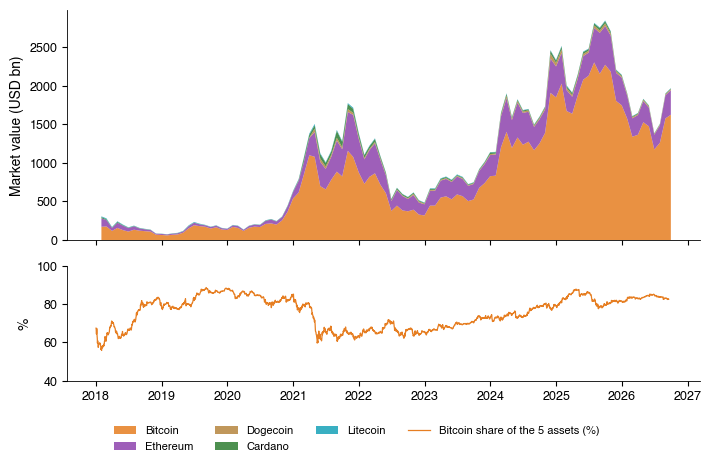

{'start': '2018-01-01',
 'total_end': np.float64(1970.1983113131482),
 'total_peak': 3135.03803985598,
 'total_peak_date': '2025-10-06',
 'btc_share_end': np.float64(82.47931391018477),
 'btc_share_min': 55.77432147709041,
 'btc_share_min_date': '2018-02-01',
 'btc_share_max': 88.52103488826371,
 'btc_share_max_date': '2019-09-05',
 'eth_share_end': np.float64(16.17761661243015),
 'hhi_end': np.float64(0.7065262133557164),
 'neff_end': np.float64(1.4153756521649787),
 'mv_end': {'BTC': np.float64(1625.006049841131),
  'ETH': np.float64(318.73112930881416),
  'DOGE': np.float64(13.633802583006075),
  'ADA': np.float64(8.32487624237569),
  'LTC': np.float64(4.502453337821162)},
 'btc_price_end': np.float64(80901.4609375),
 'btc_supply_end': np.float64(20086238.6291951),
 'eth_price_end': np.float64(2611.3471679688),
 'eth_supply_end': np.float64(122056206.55055785),
 'end': '2026-09-18'}

In [4]:
def fig_market_value():
    """Valoarea de piata (pret x oferta curenta) a activelor din universul indicelui, 2018-2026."""
    mv = market_values()
    m = mv.resample('ME').last()
    tot = mv.sum(axis=1)
    share = 100 * mv['BTC'] / tot
    fig, axes = plt.subplots(2, 1, figsize=(7.2, 4.2), sharex=True, gridspec_kw={'height_ratios': [2, 1]})
    axes[0].stackplot(m.index, [m[k] for k in CRIX_UNIVERSE], labels=[LABELS[k] for k in CRIX_UNIVERSE],
                      colors=[COL[k] for k in CRIX_UNIVERSE], alpha=0.85, lw=0)
    axes[0].set_ylabel('Market value (USD bn)')
    axes[1].plot(share.index, share.values, color=Orange, lw=0.9, label=f'Bitcoin share of the {len(CRIX_UNIVERSE)} assets (%)')
    axes[1].set_ylabel('%')
    axes[1].set_ylim(40, 100)
    fig.tight_layout()
    fig_legend_bottom(fig, ncol=4, y=0.0)
    save_fig('ch16_market_value')
    hhi = ((mv.div(tot, axis=0)) ** 2).sum(axis=1)
    return dict(start=str(mv.index[0].date()), total_end=tot.iloc[-1], total_peak=tot.max(),
                total_peak_date=str(tot.idxmax().date()), btc_share_end=share.iloc[-1], btc_share_min=share.min(),
                btc_share_min_date=str(share.idxmin().date()), btc_share_max=share.max(),
                btc_share_max_date=str(share.idxmax().date()), eth_share_end=100 * mv['ETH'].iloc[-1] / tot.iloc[-1],
                hhi_end=hhi.iloc[-1], neff_end=1 / hhi.iloc[-1], mv_end={k: mv[k].iloc[-1] for k in CRIX_UNIVERSE},
                btc_price_end=price('BTC').iloc[-1], btc_supply_end=1e9 * mv['BTC'].iloc[-1] / price('BTC').iloc[-1],
                eth_price_end=price('ETH').iloc[-1], eth_supply_end=1e9 * mv['ETH'].iloc[-1] / price('ETH').iloc[-1],
                end=str(mv.index[-1].date()))


fig_market_value()

## 2. Stylised facts: crypto vs shares and gold

In [5]:
STYL = ['BTC', 'ETH', 'SOL', 'DOGE', 'SPX', 'GOLD']


def stylised_table(start='2018-01-01'):
    """Momente, cozi, autocorelatii, scaderi maxime si VaR 1% / ES 2.5% istorice, fiecare serie pe calendarul ei."""
    rows = {}
    for k in STYL:
        p = price(k, start)
        r = 100 * np.log(p).diff().dropna()
        ppy = periods_per_year(r)
        q = np.quantile(r, 0.01)
        q25 = np.quantile(r, 0.025)
        mdd, mdd_date = max_drawdown(p)
        rows[k] = dict(N=len(r), start=str(r.index[0].date()), ppy=ppy, ann_mean=r.mean() * ppy,
                       ann_vol=r.std() * np.sqrt(ppy), skew=stats.skew(r), kurt=stats.kurtosis(r),
                       acf1=r.autocorr(1), acf1_abs=r.abs().autocorr(1), var1=-q, es2_5=-r[r <= q25].mean(),
                       min=r.min(), min_date=str(r.idxmin().date()), mdd=mdd, mdd_date=str(mdd_date.date()),
                       hill_left=hill(-r.values), share5sd=100 * (np.abs(r - r.mean()) > 5 * r.std()).mean(),
                       # aceleasi masuri ca pierderi simple, in % din pozitie: 1 - exp(r/100)
                       var1_simple=100 * (1 - np.exp(q / 100)),
                       es2_5_simple=100 * (1 - np.exp(r[r <= q25] / 100)).mean(),
                       min_simple=100 * (np.exp(r.min() / 100) - 1))
    t = pd.DataFrame(rows).T
    t.to_csv(os.path.join(HERE, 'ch16_stylised_facts.csv'))
    return t


t = stylised_table()
t

,N,start,ppy,ann_mean,ann_vol,skew,kurt,acf1,acf1_abs,var1,es2_5,min,min_date,mdd,mdd_date,hill_left,share5sd,var1_simple,es2_5_simple,min_simple
BTC,3182,2018-01-02,365.364822,20.4265,64.121262,-0.945702,14.833063,-0.046503,0.167694,10.223854,10.287778,-46.473021,2020-03-12,-81.532712,2018-12-15,2.72793,0.157134,9.718583,9.675489,-37.169541
ETH,3182,2018-01-02,365.364822,13.98315,84.337038,-0.824251,11.060023,-0.046054,0.155464,13.488352,13.684192,-55.073172,2020-03-12,-93.96254,2018-12-14,2.668015,0.125707,12.618231,12.647047,-42.34722
SOL,2351,2020-04-12,365.405426,77.345701,117.063048,-0.218955,7.88839,-0.041977,0.276674,14.46206,17.144676,-54.958202,2022-11-09,-96.272497,2022-12-29,2.848669,0.255211,13.464946,15.479812,-42.280899
DOGE,3182,2018-01-02,365.364822,26.220821,123.921147,4.876032,106.366343,0.027021,0.370681,13.791233,16.350159,-51.511165,2021-01-30,-92.258478,2022-06-18,2.832624,0.408548,12.882493,14.845292,-40.256611
SPX,2189,2018-01-03,251.425236,11.98057,19.187759,-0.645527,14.922445,-0.144612,0.357301,3.429764,3.83186,-12.765218,2020-03-16,-33.92496,2020-03-23,2.869843,0.411147,3.371614,3.743879,-11.984054
GOLD,2269,2018-01-02,260.531987,13.88689,17.205721,-0.548312,10.255483,-0.021102,0.125691,2.998658,3.181783,-11.140951,2026-01-30,-27.700612,2026-07-16,2.746899,0.264434,2.954144,3.121675,-10.542766


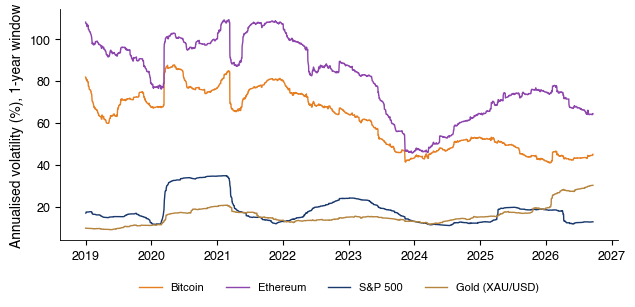

{'BTC': {'last': np.float64(45.08038507447969), 'min': 41.05212934873849, 'max': 87.77537444424225, 'min_date': '2026-01-19'}, 'ETH': {'last': np.float64(64.49569028563712), 'min': 45.7117162746907, 'max': 109.32164328592238, 'min_date': '2023-12-20'}, 'SPX': {'last': np.float64(12.902675341021537), 'min': 11.10037329316607, 'max': 34.910212692846976, 'min_date': '2024-07-09'}, 'GOLD': {'last': np.float64(30.31229786348122), 'min': 9.120586866740108, 'max': 30.31229786348122, 'min_date': '2019-05-15'}, 'btc_eth_ratio_last': np.float64(1.430681884794914), 'btc_spx_ratio_last': np.float64(3.4938788958872284)}


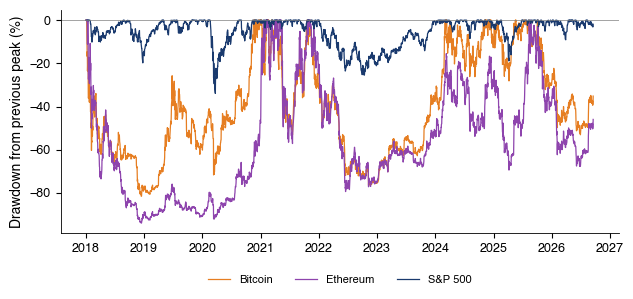

{'BTC': {'min': -81.5327115591944,
  'min_date': '2018-12-15',
  'last': np.float64(-35.15044383776625),
  'share_below50': np.float64(36.380772855796415)},
 'ETH': {'min': -93.96254040497699,
  'min_date': '2018-12-14',
  'last': np.float64(-45.94993411408358),
  'share_below50': np.float64(61.262959472196044)},
 'SPX': {'min': -33.9249600261347,
  'min_date': '2020-03-23',
  'last': np.float64(-1.903963229904937),
  'share_below50': np.float64(0.0)}}

In [6]:
def fig_rolling_vol(start='2018-01-01'):
    """Volatilitatea anualizata pe ferestre mobile de un an calendaristic."""
    fig, ax = plt.subplots(figsize=(7.2, 3.0))
    out = {}
    for k in ['BTC', 'ETH', 'SPX', 'GOLD']:
        r = log_returns(k, start)
        ppy = periods_per_year(r)
        v = 100 * r.rolling('365D', min_periods=int(0.9 * ppy)).std() * np.sqrt(ppy)
        v = v.loc['2019-01-01':]
        ax.plot(v.index, v.values, color=COL[k], lw=1.0, label=LABELS[k])
        out[k] = dict(last=v.iloc[-1], min=v.min(), max=v.max(), min_date=str(v.idxmin().date()))
    ax.set_ylabel('Annualised volatility (%), 1-year window')
    legend_outside_bottom(ax, ncol=4, y=-0.14)
    save_fig('ch16_rolling_vol')
    out['btc_eth_ratio_last'] = out['ETH']['last'] / out['BTC']['last']
    out['btc_spx_ratio_last'] = out['BTC']['last'] / out['SPX']['last']
    return out


def fig_drawdowns(start='2018-01-01'):
    """Scaderea de la maximul anterior pentru Bitcoin, Ethereum si S&P 500."""
    fig, ax = plt.subplots(figsize=(7.2, 2.9))
    out = {}
    for k in ['BTC', 'ETH', 'SPX']:
        p = price(k, start)
        dd = 100 * (p / p.cummax() - 1)
        ax.plot(dd.index, dd.values, color=COL[k], lw=0.9, label=LABELS[k])
        out[k] = dict(min=dd.min(), min_date=str(dd.idxmin().date()), last=dd.iloc[-1],
                      share_below50=100 * (dd < -50).mean())
    ax.axhline(0, color=Gray, lw=0.5)
    ax.set_ylabel('Drawdown from previous peak (%)')
    legend_outside_bottom(ax, ncol=3, y=-0.14)
    save_fig('ch16_drawdowns')
    return out


print(fig_rolling_vol())
fig_drawdowns()

## 3. Day of the week and correlations

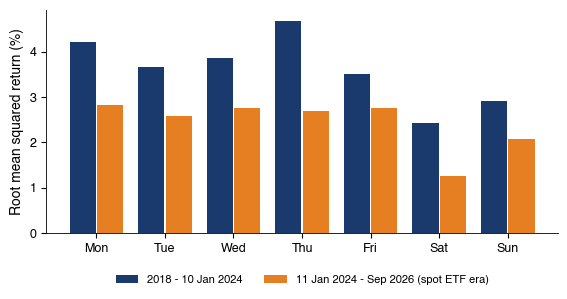

{'ratio_pre': 0.44917976393266673,
 'ratio_post': 0.3945466150051555,
 'pre': [4.210785207384411,
  3.6645981136683408,
  3.8645614356818263,
  4.6812465505682015,
  3.5051702619422036,
  2.4299493686905316,
  2.917442894048991],
 'post': [2.815342740128887,
  2.5876346352361748,
  2.765335071826396,
  2.692097883386533,
  2.7671254737252875,
  1.2599252326064567,
  2.0656473590581763],
 'wd_pre': np.float64(4.007073104772058),
 'we_pre': np.float64(2.684783694679747),
 'wd_post': np.float64(2.726672309948462),
 'we_post': np.float64(1.7108931298801882)}

In [7]:
def fig_weekday(start='2018-01-01'):
    """Dispersia randamentelor Bitcoin pe zile ale saptamanii, inainte si dupa lansarea ETF-urilor spot."""
    r = 100 * log_returns('BTC', start)
    pre, post = r.loc[:'2024-01-10'], r.loc[ETF_START:]
    days = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
    v_pre = pre.groupby(pre.index.dayofweek).apply(lambda x: np.sqrt((x ** 2).mean()))
    v_post = post.groupby(post.index.dayofweek).apply(lambda x: np.sqrt((x ** 2).mean()))
    fig, ax = plt.subplots(figsize=(6.6, 2.9))
    x = np.arange(7)
    ax.bar(x - 0.2, v_pre.values, 0.38, color=MainBlue, label='2018 - 10 Jan 2024')
    ax.bar(x + 0.2, v_post.values, 0.38, color=Orange, label='11 Jan 2024 - Sep 2026 (spot ETF era)')
    ax.set_xticks(x)
    ax.set_xticklabels(days)
    ax.set_ylabel('Root mean squared return (%)')
    legend_outside_bottom(ax, ncol=2, y=-0.14)
    save_fig('ch16_weekday')

    def ratio(x):
        """Raportul dispersiilor (centrate): weekend / zile lucratoare."""
        we = x[x.index.dayofweek >= 5]
        wd = x[x.index.dayofweek < 5]
        return we.var(ddof=1) / wd.var(ddof=1)
    return dict(ratio_pre=ratio(pre), ratio_post=ratio(post), pre=v_pre.tolist(), post=v_post.tolist(),
                wd_pre=np.sqrt((pre[pre.index.dayofweek < 5] ** 2).mean()),
                we_pre=np.sqrt((pre[pre.index.dayofweek >= 5] ** 2).mean()),
                wd_post=np.sqrt((post[post.index.dayofweek < 5] ** 2).mean()),
                we_post=np.sqrt((post[post.index.dayofweek >= 5] ** 2).mean()))


fig_weekday()

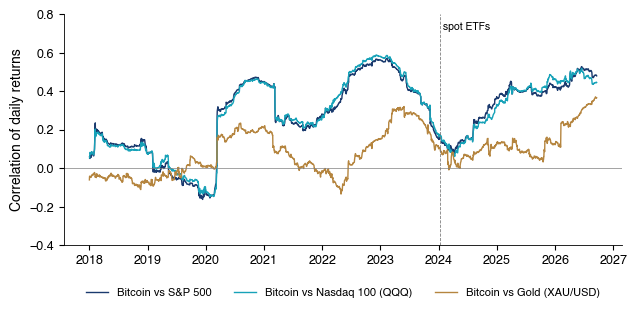

{'SPX': {'p1': np.float64(0.022891398561799288),
  'p1_n': 753,
  'p2': np.float64(0.3915765252495031),
  'p2_n': 1006,
  'p3': np.float64(0.383856462209531),
  'p3_n': 674,
  'last': np.float64(0.4798528983979601),
  'max': 0.5705525534112205,
  'max_date': '2023-02-09'},
 'QQQ': {'p1': np.float64(0.026585074790159677),
  'p1_n': 754,
  'p2': np.float64(0.40180442680585915),
  'p2_n': 1006,
  'p3': np.float64(0.3788257054777565),
  'p3_n': 674,
  'last': np.float64(0.4454113497509316),
  'max': 0.5878568777315023,
  'max_date': '2022-12-05'},
 'GOLD': {'p1': np.float64(-0.019865700964636634),
  'p1_n': 780,
  'p2': np.float64(0.12216042926899155),
  'p2_n': 1042,
  'p3': np.float64(0.21797159211189007),
  'p3_n': 700,
  'last': np.float64(0.3658180592083669),
  'max': 0.3705709745685086,
  'max_date': '2026-09-11'}}

In [8]:
def fig_rolling_corr():
    """Corelatia pe 250 de zile comune: Bitcoin cu S&P 500, Nasdaq 100 si aurul (join pe preturi)."""
    fig, ax = plt.subplots(figsize=(7.2, 3.0))
    out = {}
    for k, c in [('SPX', MainBlue), ('QQQ', Teal), ('GOLD', Amber)]:
        r = joint_returns(['BTC', k], '2016-01-01')
        rc = r['BTC'].rolling(250).corr(r[k]).loc['2018-01-01':]
        ax.plot(rc.index, rc.values, color=c, lw=1.0, label=f'Bitcoin vs {LABELS[k]}')
        per = {}
        for lab, a, b in [('p1', '2017-01-01', '2019-12-31'), ('p2', '2020-01-01', '2023-12-31'),
                          ('p3', ETF_START, END)]:
            x = r.loc[a:b]
            per[lab] = x['BTC'].corr(x[k])
            per[lab + '_n'] = len(x)
        out[k] = dict(per, last=rc.iloc[-1], max=rc.max(), max_date=str(rc.idxmax().date()))
    ax.axhline(0, color=Gray, lw=0.5)
    ax.axvline(pd.Timestamp(ETF_START), color=Gray, lw=0.6, ls='--')
    ax.text(pd.Timestamp(ETF_START), 0.72, ' spot ETFs', fontsize=7.5, color='black')
    ax.set_ylabel('Correlation of daily returns')
    ax.set_ylim(-0.4, 0.8)
    legend_outside_bottom(ax, ncol=3, y=-0.14)
    save_fig('ch16_rolling_corr')
    return out


fig_rolling_corr()

## 4. Crypto indices and the CRIX rule

- Laspeyres index with monthly reallocation and a divisor; top-$k$ indices and tracking error.
- Published CRIX rule (Trimborn & Härdle, 2018): free weights for added coins, Epanechnikov kernel likelihood, $\mathrm{AIC} = -2\log L + 2s$, quarterly review, ECRIX and EFCRIX stopping rules.

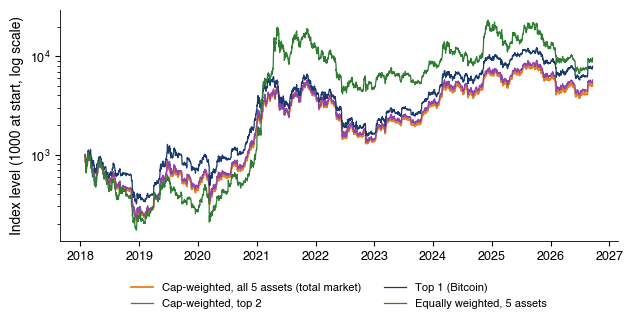

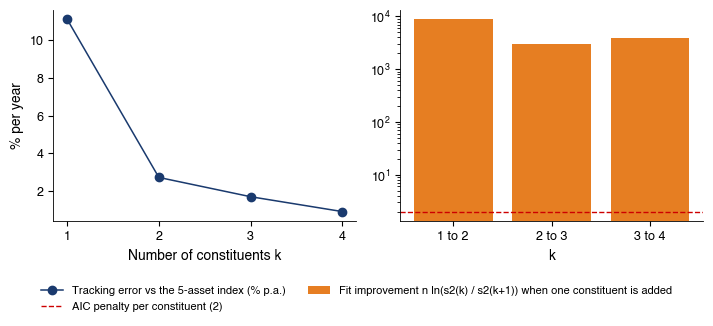

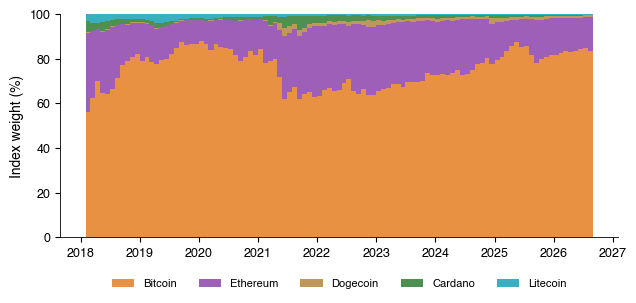

{'aic': {'1': np.float64(-32436.59706166621),
  '2': np.float64(-41329.45147225557),
  '3': np.float64(-44320.548795933835),
  '4': np.float64(-48299.388597705314)},
 'te': {'1': np.float64(11.126457577950458),
  '2': np.float64(2.7139930556502425),
  '3': np.float64(1.6883241992412648),
  '4': np.float64(0.8978427438082407)},
 'k_aic': 4,
 'tot_cagr': np.float64(21.36104937450185),
 'ew_cagr': np.float64(30.016913072188032),
 'tot_vol': np.float64(65.72233698067389),
 'ew_vol': np.float64(82.45887604634147)}

In [9]:
def crix_index(k=None, weighting='cap', mv=None, px=None):
    """Indice Laspeyres cu reponderare lunara: primii k constituenti dupa valoarea de piata la sfarsitul lunii
    anterioare; cantitatile sunt fixe in cursul lunii, iar divizorul pastreaza continuitatea la reponderare."""
    if mv is None:
        mv = market_values()
    if px is None:
        px = pd.concat([price(a) for a in CRIX_UNIVERSE], axis=1).reindex(mv.index)
    months = mv.index.to_period('M')
    level = pd.Series(np.nan, index=mv.index)
    wts = {}
    val = 1000.0
    first = True
    for per in months.unique():
        idx = mv.index[months == per]
        prev = mv.loc[:idx[0] - pd.Timedelta(days=1)]
        if prev.empty:
            continue
        base = prev.iloc[-1]
        members = base.sort_values(ascending=False).index[:(k or len(base))]
        w = base[members] / base[members].sum() if weighting == 'cap' else pd.Series(1 / len(members), index=members)
        p0 = px.loc[prev.index[-1], members]
        rel = (px.loc[idx, members] / p0).mul(w, axis=1).sum(axis=1)
        if first:
            level.loc[prev.index[-1]] = val
            first = False
        level.loc[idx] = val * rel
        val = level.loc[idx[-1]]
        wts[str(per)] = w.reindex(CRIX_UNIVERSE).fillna(0)
    return level.dropna(), pd.DataFrame(wts).T


def crix_aic(mv=None, px=None):
    """AIC(k) = n ln(s2_k) + 2k, cu s2_k media patratelor diferentelor dintre randamentele log ale indicelui total
    (toti cei 7 constituenti) si ale indicelui cu k constituenti; pe intreaga perioada si pe fiecare an."""
    if mv is None:
        mv = market_values()
    if px is None:
        px = pd.concat([price(a) for a in CRIX_UNIVERSE], axis=1).reindex(mv.index)
    tot, _ = crix_index(None, 'cap', mv, px)
    rt = np.log(tot).diff().dropna()
    res = {}
    te = {}
    for k in range(1, len(CRIX_UNIVERSE)):
        lk, _ = crix_index(k, 'cap', mv, px)
        d = (np.log(lk).diff() - np.log(tot).diff()).dropna()
        res[k] = d
        te[k] = 100 * d.std() * np.sqrt(365)
    n = len(rt)
    aic = {k: n * np.log((d ** 2).mean()) + 2 * k for k, d in res.items()}
    bic = {k: n * np.log((d ** 2).mean()) + k * np.log(n) for k, d in res.items()}
    yearly = {}
    for y in sorted(set(rt.index.year)):
        a = {k: len(d.loc[str(y)]) * np.log((d.loc[str(y)] ** 2).mean()) + 2 * k for k, d in res.items()}
        yearly[y] = min(a, key=a.get)
    return dict(aic=aic, bic=bic, te=te, k_aic=min(aic, key=aic.get), k_bic=min(bic, key=bic.get), n=n,
                yearly=yearly)


def fig_crix():
    """Indicele total (7 active), Bitcoin singur (k = 1), indicele cu ponderi egale; AIC(k) si ponderile in timp."""
    mv = market_values()
    px = pd.concat([price(a) for a in CRIX_UNIVERSE], axis=1).reindex(mv.index)
    tot, w = crix_index(None, 'cap', mv, px)
    k1, _ = crix_index(1, 'cap', mv, px)
    k2, _ = crix_index(2, 'cap', mv, px)
    ew, _ = crix_index(None, 'equal', mv, px)
    a = crix_aic(mv, px)
    # indicele
    fig, ax = plt.subplots(figsize=(7.2, 3.0))
    for s, lab, c, lw in [(tot, f'Cap-weighted, all {len(CRIX_UNIVERSE)} assets (total market)', Orange, 1.3), (k2, 'Cap-weighted, top 2', Purple, 0.9),
                          (k1, 'Top 1 (Bitcoin)', MainBlue, 0.9), (ew, f'Equally weighted, {len(CRIX_UNIVERSE)} assets', Forest, 0.9)]:
        ax.plot(s.index, s.values, color=c, lw=lw, label=lab)
    ax.set_yscale('log')
    ax.set_ylabel('Index level (1000 at start, log scale)')
    legend_outside_bottom(ax, ncol=2, y=-0.14)
    save_fig('ch16_crix_index')
    # eroarea de urmarire si castigul AIC la adaugarea fiecarui constituent
    fig, axes = plt.subplots(1, 2, figsize=(7.2, 2.8))
    ks = list(a['te'])
    axes[0].plot(ks, [a['te'][k] for k in ks], 'o-', color=MainBlue, label=f'Tracking error vs the {len(CRIX_UNIVERSE)}-asset index (% p.a.)')
    axes[0].set_xlabel('Number of constituents k')
    axes[0].set_ylabel('% per year')
    axes[0].set_xticks(ks)
    # imbunatatirea ajustarii n ln(s2_k / s2_(k+1)) = AIC(k) - AIC(k+1) + 2, comparata cu penalizarea 2
    fit = [a['aic'][k] - a['aic'][k + 1] + 2 for k in ks[:-1]]
    axes[1].bar([f'{k} to {k + 1}' for k in ks[:-1]], fit, color=Orange,
                label='Fit improvement n ln(s2(k) / s2(k+1)) when one constituent is added')
    axes[1].axhline(2, color=IDAred, lw=1.0, ls='--', label='AIC penalty per constituent (2)')
    axes[1].set_yscale('log')
    axes[1].set_xlabel('k')
    fig.tight_layout()
    fig_legend_bottom(fig, ncol=2, y=0.0)
    save_fig('ch16_crix_aic')
    # ponderile
    fig, ax = plt.subplots(figsize=(7.2, 2.9))
    wi = w.copy()
    wi.index = pd.PeriodIndex(wi.index, freq='M').to_timestamp()
    ax.stackplot(wi.index, [100 * wi[c] for c in CRIX_UNIVERSE], labels=[LABELS[c] for c in CRIX_UNIVERSE],
                 colors=[COL[c] for c in CRIX_UNIVERSE], alpha=0.85, lw=0, step='post')
    ax.set_ylim(0, 100)
    ax.set_ylabel('Index weight (%)')
    legend_outside_bottom(ax, ncol=5, y=-0.14)
    save_fig('ch16_crix_weights')
    rt = np.log(tot).diff().dropna()
    re_ = np.log(ew).diff().dropna()
    yrs = (tot.index[-1] - tot.index[0]).days / 365.25
    return dict(aic={str(k): v for k, v in a['aic'].items()}, te={str(k): v for k, v in a['te'].items()},
                k_aic=a['k_aic'], k_bic=a['k_bic'], n=a['n'], yearly={str(k): v for k, v in a['yearly'].items()},
                gain={str(k): a['aic'][k] - a['aic'][k + 1] for k in list(a['aic'])[:-1]},
                tot_end=tot.iloc[-1], k1_end=k1.iloc[-1], k2_end=k2.iloc[-1], ew_end=ew.iloc[-1],
                tot_cagr=100 * ((tot.iloc[-1] / 1000) ** (1 / yrs) - 1), ew_cagr=100 * ((ew.iloc[-1] / 1000) ** (1 / yrs) - 1),
                tot_vol=100 * rt.std() * np.sqrt(365), ew_vol=100 * re_.std() * np.sqrt(365),
                w_btc_mean=100 * w['BTC'].mean(), w_btc_min=100 * w['BTC'].min(), w_btc_max=100 * w['BTC'].max(),
                w_last={c: 100 * w[c].iloc[-1] for c in CRIX_UNIVERSE}, start=str(tot.index[0].date()), years=yrs,
                ew_year={str(d.year): 100 * v for d, v in ew.resample('YE').last().pct_change().dropna().items()},
                tot_year={str(d.year): 100 * v for d, v in tot.resample('YE').last().pct_change().dropna().items()},
                k1_year={str(d.year): 100 * v for d, v in k1.resample('YE').last().pct_change().dropna().items()})


cx = fig_crix()
{k: v for k, v in cx.items() if k in ('te', 'aic', 'k_aic', 'tot_cagr', 'ew_cagr', 'tot_vol', 'ew_vol')}

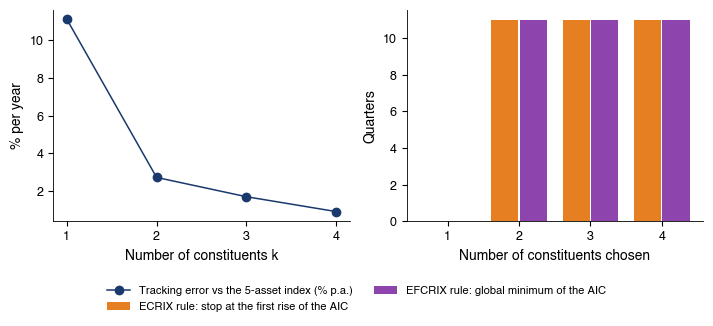

({'1': 0, '2': 11, '3': 11, '4': 11}, {'1': 0, '2': 11, '3': 11, '4': 11})

In [10]:
from scipy.optimize import least_squares, brentq


def sj_bandwidth(x):
    """Latimea de banda plug-in Sheather-Jones ('solve-the-equation') pentru nucleul gaussian (ca bw.SJ din R),
    convertita la nucleul Epanechnikov cu varianta 1 (factor (R(K_E)/R(K_G))^(1/5))."""
    x = np.asarray(x, float)
    n = len(x)
    d = (x[:, None] - x[None, :]).ravel()
    phi = lambda u: np.exp(-u ** 2 / 2) / np.sqrt(2 * np.pi)
    psi4 = lambda h: np.sum(((d / h) ** 4 - 6 * (d / h) ** 2 + 3) * phi(d / h)) / (n * (n - 1) * h ** 5)
    psi6 = lambda h: np.sum(((d / h) ** 6 - 15 * (d / h) ** 4 + 45 * (d / h) ** 2 - 15) * phi(d / h)) / (n * (n - 1) * h ** 7)
    scale = min(np.std(x, ddof=1), stats.iqr(x) / 1.349)
    a = 1.24 * scale * n ** (-1 / 7)
    b = 1.23 * scale * n ** (-1 / 9)
    c1 = 1 / (2 * np.sqrt(np.pi) * n)
    td = -psi6(b)
    alph2 = 1.357 * (psi4(a) / td) ** (1 / 7)
    f = lambda h: (c1 / psi4(alph2 * h ** (5 / 7))) ** 0.2 - h
    lo, hi = 0.1 * scale * n ** (-0.2), 3 * scale * n ** (-0.2)
    try:
        hg = brentq(f, lo, hi)
    except ValueError:
        hg = 1.06 * scale * n ** (-0.2)
    return hg * ((3 / (5 * np.sqrt(5))) / (1 / (2 * np.sqrt(np.pi)))) ** 0.2


def epa_loglik(base, x):
    """Log-verosimilitatea valorilor x sub densitatea nucleu Epanechnikov (suport +-sqrt(5)) a reziduurilor de baza."""
    h = sj_bandwidth(base)
    u = (x[:, None] - base[None, :]) / h
    k = 3 / (4 * np.sqrt(5)) * (1 - u ** 2 / 5) * (np.abs(u) <= np.sqrt(5))
    f = k.mean(axis=1) / h
    return float(np.sum(np.log(np.maximum(f, 1e-300)))), h


def crix_window(mv, px, days):
    """Pentru zilele unei ferestre trimestriale: randamentele log ale indicelui total (toate monedele, pondere 1)
    si, pentru fiecare zi, cantitatile Q = valoare de piata / pret la sfarsitul lunii anterioare, ordonate dupa
    valoarea de piata (abordarea top-down, ec. 23)."""
    rows = []
    for t in days:
        prevm = mv.loc[:t.to_period('M').start_time - pd.Timedelta(days=1)]
        if prevm.empty:
            return None
        base = prevm.iloc[-1]
        order = base.sort_values(ascending=False).index.tolist()
        q = (base * 1e9 / px.loc[prevm.index[-1]])[order]
        i = px.index.get_loc(t)
        rows.append((order, q.values, px.iloc[i][order].values, px.iloc[i - 1][order].values))
    return rows


def crix_residuals(rows, k, beta):
    """eps_hat(k, beta) = randamentul indicelui total - randamentul CRIX(k, beta), ec. (11) si (22): primul
    constituent cu pondere 1, urmatorii k - 1 cu ponderile beta."""
    e = []
    for order, q, p1, p0 in rows:
        tot = np.log((p1 * q).sum() / (p0 * q).sum())
        w = np.concatenate([[1.0], beta, np.zeros(len(q) - k)])
        a1, a0 = (w * p1 * q).sum(), (w * p0 * q).sum()
        e.append(tot - np.log(a1 / a0) if a1 > 0 and a0 > 0 else 1.0)
    return np.array(e)


def crix_rule(kmax=4):
    """Numarul de constituenti ales trimestrial (fereastra: ultimele trei luni) de ECRIX (oprire la prima crestere
    a AIC) si EFCRIX (minimul global), cu k1 = 1 si pasul s = 1 (Trimborn & Hardle, 2018, Sectiunile 3-5)."""
    mv = market_values()
    px = pd.concat([price(a) for a in CRIX_UNIVERSE], axis=1).reindex(mv.index)
    qends = pd.date_range('2018-06-30', END, freq='QE')
    res = []
    for qe in qends:
        days = mv.loc[qe.to_period('Q').start_time:qe].index      # trimestrul calendaristic incheiat la qe
        rows = crix_window(mv, px, days)
        if rows is None or len(rows) < 60:
            continue
        base = crix_residuals(rows, 1, np.array([]))
        ll0, h = epa_loglik(base, base)
        aic = {1: -2 * ll0}
        for k in range(2, kmax + 1):
            fit = least_squares(lambda b: crix_residuals(rows, k, b), np.ones(k - 1))
            ll, _ = epa_loglik(base, crix_residuals(rows, k, fit.x))
            aic[k] = -2 * ll + 2 * (k - 1)
        ek = kmax
        for k in range(2, kmax + 1):
            if aic[k] > aic[k - 1]:
                ek = k - 1
                break
        res.append(dict(q=str(qe.date()), n=len(rows), h=h, aic=aic, ecrix=ek, efcrix=min(aic, key=aic.get)))
    ec = pd.Series([r['ecrix'] for r in res])
    ef = pd.Series([r['efcrix'] for r in res])
    return dict(quarters=res, n_q=len(res), first=res[0]['q'], last=res[-1]['q'],
                ecrix_counts={str(k): int((ec == k).sum()) for k in range(1, kmax + 1)},
                efcrix_counts={str(k): int((ef == k).sum()) for k in range(1, kmax + 1)},
                ecrix_mode=int(ec.mode().iloc[0]), efcrix_mode=int(ef.mode().iloc[0]),
                ecrix_last=int(ec.iloc[-1]), efcrix_last=int(ef.iloc[-1]))


def fig_crix_rule(cr, te):
    """Stanga: eroarea de urmarire a indicelui cu primii k constituenti; dreapta: numarul de trimestre in care
    regulile ECRIX si EFCRIX aleg k constituenti."""
    fig, axes = plt.subplots(1, 2, figsize=(7.2, 2.8))
    ks = [1, 2, 3, 4]
    axes[0].plot(ks, [te[str(k)] for k in ks], 'o-', color=MainBlue, label='Tracking error vs the 5-asset index (% p.a.)')
    axes[0].set_xlabel('Number of constituents k')
    axes[0].set_ylabel('% per year')
    axes[0].set_xticks(ks)
    x = np.arange(len(ks))
    axes[1].bar(x - 0.2, [cr['ecrix_counts'][str(k)] for k in ks], 0.38, color=Orange,
                label='ECRIX rule: stop at the first rise of the AIC')
    axes[1].bar(x + 0.2, [cr['efcrix_counts'][str(k)] for k in ks], 0.38, color=Purple,
                label='EFCRIX rule: global minimum of the AIC')
    axes[1].set_xticks(x)
    axes[1].set_xticklabels([str(k) for k in ks])
    axes[1].set_xlabel('Number of constituents chosen')
    axes[1].set_ylabel('Quarters')
    fig.tight_layout()
    fig_legend_bottom(fig, ncol=2, y=0.0)
    save_fig('ch16_crix_rule')


cr = crix_rule()
fig_crix_rule(cr, {str(k): v for k, v in cx['te'].items()})
cr['ecrix_counts'], cr['efcrix_counts']

## 5. Stablecoins

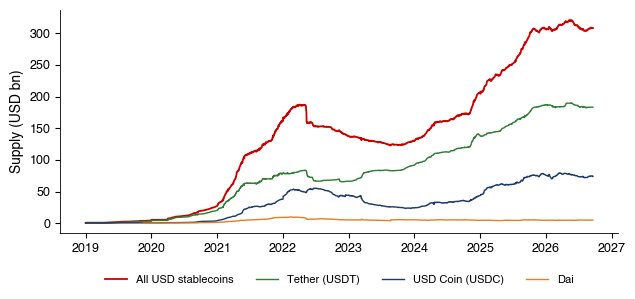

{'total_end': np.float64(308.019607521),
 'total_2020': np.float64(4.171183915),
 'n_big': 45,
 'other': 2.62885040499998,
 'usdt_end': np.float64(183.32932036),
 'usdc_end': np.float64(73.916109054),
 'dai_end': np.float64(4.771140262),
 'usdt_share': np.float64(59.51871760225558),
 'usdc_share': np.float64(23.997209024740606),
 'usdc_peak': 79.62020699,
 'usdc_peak_date': '2026-03-18',
 'n_coins': 339,
 'mech': {'algorithmic': 0.147140204,
  'crypto-backed': 22.362326069,
  'fiat-backed': 282.881290843},
 'end': '2026-09-18',
 'tot_peak22': 187.391942652,
 'tot_peak22_date': '2022-04-02',
 'tot_trough': 122.660540921,
 'tot_trough_date': '2023-08-19',
 'usdc_peak22': 55.19135477,
 'usdc_peak22_date': '2022-06-20',
 'usdc_trough': 23.171550057,
 'usdc_trough_date': '2023-11-15'}

In [11]:
def fig_stablecoin_supply():
    """Oferta stablecoin-urilor ancorate la USD: total, USDT, USDC, DAI (miliarde USD)."""
    tot = stablecoin_chart()['value'].loc['2019-01-01':]
    parts = {'USDT': stablecoin_chart(1)['value'], 'USDC': stablecoin_chart(2)['value'], 'DAI': stablecoin_chart(5)['value']}
    fig, ax = plt.subplots(figsize=(7.2, 2.9))
    ax.plot(tot.index, tot.values, color=IDAred, lw=1.3, label='All USD stablecoins')
    for k, s in parts.items():
        s = s.loc['2019-01-01':]
        ax.plot(s.index, s.values, color=COL[k], lw=1.0, label=LABELS[k])
    ax.set_ylabel('Supply (USD bn)')
    legend_outside_bottom(ax, ncol=4, y=-0.14)
    save_fig('ch16_stablecoin_supply')
    # clasificarea pe mecanisme la aceeasi data ca totalul (END): valoarea fiecarei monede de peste 100 mil. USD,
    # restul monedelor = totalul minus suma lor
    lst = stablecoin_list()
    lst = lst.assign(mechanism=lst['mechanism'].replace({'crytpo-backed': 'crypto-backed'}))
    big = lst[lst['supply'] >= 0.1].copy()
    vals = []
    for i in big['id']:
        v = stablecoin_chart(int(i))['value'].loc[:END].dropna()
        vals.append(float(v.iloc[-1]) if len(v) and v.index[-1] >= pd.Timestamp(END) - pd.Timedelta(days=3) else 0.0)
    big['value'] = vals
    big = big[big['value'] > 0].sort_values('value', ascending=False)
    mech = big.groupby('mechanism')['value'].sum()
    return dict(total_end=tot.iloc[-1], total_2020=tot.loc[:'2020-01-01'].iloc[-1],
                n_big=int(len(big)), other=float(tot.iloc[-1] - big['value'].sum()),
                usdt_end=parts['USDT'].iloc[-1], usdc_end=parts['USDC'].iloc[-1], dai_end=parts['DAI'].iloc[-1],
                usdt_share=100 * parts['USDT'].iloc[-1] / tot.iloc[-1], usdc_share=100 * parts['USDC'].iloc[-1] / tot.iloc[-1],
                usdc_peak=parts['USDC'].max(), usdc_peak_date=str(parts['USDC'].idxmax().date()),
                n_coins=int(len(lst)), mech={k: float(v) for k, v in mech.items()},
                top=[dict(symbol=r.symbol, name=r.name, mechanism=r.mechanism, supply=r.value) for r in big.head(12).itertuples()],
                end=str(tot.index[-1].date()),
                tot_peak22=tot.loc[:'2022-12-31'].max(), tot_peak22_date=str(tot.loc[:'2022-12-31'].idxmax().date()),
                tot_trough=tot.loc['2022-06-01':'2024-06-30'].min(),
                tot_trough_date=str(tot.loc['2022-06-01':'2024-06-30'].idxmin().date()),
                usdc_peak22=parts['USDC'].loc[:'2022-12-31'].max(),
                usdc_peak22_date=str(parts['USDC'].loc[:'2022-12-31'].idxmax().date()),
                usdc_trough=parts['USDC'].loc['2022-06-01':'2024-06-30'].min(),
                usdc_trough_date=str(parts['USDC'].loc['2022-06-01':'2024-06-30'].idxmin().date()))


ss = fig_stablecoin_supply()
{k: v for k, v in ss.items() if k != 'top'}

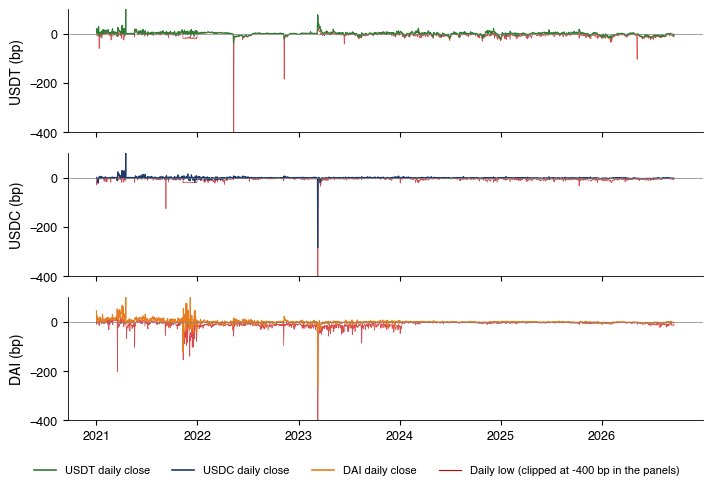

,USDT,USDC,DAI
N,2087,2087,2087
sd,7.287367,7.482593,10.83264
mad,3.081398,1.126255,2.212519
gt50,0.143747,0.143747,0.574988
gt100,0.047916,0.095831,0.143747
low_min,-515.138921,-1226.0,-1029.967719
low_min_date,2022-05-12,2023-03-11,2023-03-11
high_max,330.189504,13495.563783,26683.978839
high_max_date,2021-11-16,2021-11-16,2021-11-16
close_min,-41.278609,-285.0,-261.31348


In [12]:
def peg_stats(key, start='2021-01-01'):
    """Abaterea de la paritate (puncte de baza) pe preturile de inchidere si pe minimele zilnice."""
    d = read_market(ASSETS[key][0]).loc[start:END]
    dev = 1e4 * (d['close'] - 1)
    low = 1e4 * (d['low'] - 1)
    high = 1e4 * (d['high'] - 1)
    x = dev.values
    phi = np.corrcoef(x[1:], x[:-1])[0, 1]
    return dict(N=len(dev), sd=dev.std(), mad=np.median(np.abs(dev)), gt50=100 * (dev.abs() > 50).mean(),
                gt100=100 * (dev.abs() > 100).mean(), low_min=low.min(), low_min_date=str(low.idxmin().date()),
                high_max=high.max(), high_max_date=str(high.idxmax().date()), close_min=dev.min(),
                close_min_date=str(dev.idxmin().date()), phi=phi, half_life=np.log(0.5) / np.log(abs(phi)))


def fig_peg_deviation(start='2021-01-01'):
    """Abaterea zilnica de la 1 USD pentru USDT, USDC si DAI (inchidere si minimul zilei)."""
    fig, axes = plt.subplots(3, 1, figsize=(7.2, 4.6), sharex=True)
    out = {}
    for ax, k in zip(axes, STABLE):
        d = read_market(ASSETS[k][0]).loc[start:END]
        dev = 1e4 * (d['close'] - 1)
        low = 1e4 * (d['low'] - 1)
        ax.plot(low.index, low.clip(lower=-1500).values, color=IDAred, lw=0.5, alpha=0.7, label='Daily low')
        ax.plot(dev.index, dev.values, color=COL[k], lw=0.8, label=f'Daily close')
        ax.axhline(0, color=Gray, lw=0.5)
        ax.set_ylim(-400, 100)
        ax.set_ylabel(f'{k} (bp)')
        out[k] = peg_stats(k, start)
    h = [plt.Line2D([], [], color=COL[k], lw=1.2) for k in STABLE] + [plt.Line2D([], [], color=IDAred, lw=0.8)]
    fig.tight_layout()
    fig_legend_bottom(fig, h, ['USDT daily close', 'USDC daily close', 'DAI daily close',
                               'Daily low (clipped at -400 bp in the panels)'], ncol=4, y=0.0)
    save_fig('ch16_peg_deviation')
    return out


pd.DataFrame(fig_peg_deviation()).round(2)

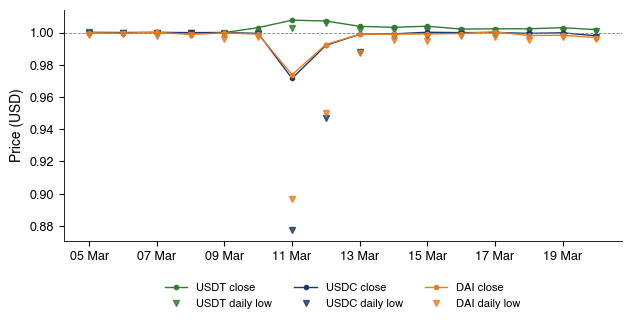

{'USDT': {'low': 0.9998157786, 'low_date': '2023-03-09', 'close_min': 0.9999858088, 'high': 1.0296284355, 'close_max': 1.00769}, 'USDC': {'low': 0.8774, 'low_date': '2023-03-11', 'close_min': 0.9715, 'high': 1.0009154368, 'close_max': 1.0001843997}, 'DAI': {'low': 0.8970032281, 'low_date': '2023-03-11', 'close_min': 0.973868652, 'high': 1.0025748001, 'close_max': 1.0004739766}}


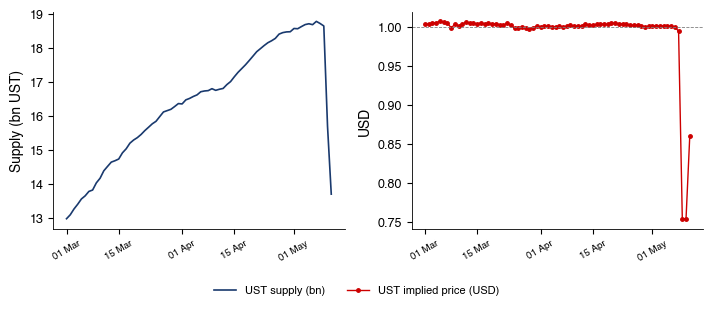

{'supply_peak': 18.770471902,
 'supply_peak_date': '2022-05-07',
 'supply_last': np.float64(13.692512964),
 'last_date': '2022-05-11',
 'px_min': 0.7539999999539609,
 'px_min_date': '2022-05-10',
 'drop_pct': np.float64(27.05291036108124)}

In [13]:
def fig_depeg_2023():
    """Martie 2023: USDC si DAI sub paritate dupa inchiderea Silicon Valley Bank; USDT peste paritate."""
    a, b = '2023-03-05', '2023-03-20'
    fig, ax = plt.subplots(figsize=(7.2, 3.0))
    out = {}
    for k in STABLE:
        d = read_market(ASSETS[k][0]).loc[a:b]
        ax.plot(d.index, d['close'], 'o-', color=COL[k], ms=3, lw=1.0, label=f'{k} close')
        ax.plot(d.index, d['low'], 'v', color=COL[k], ms=4, alpha=0.8, label=f'{k} daily low')
        out[k] = dict(low=d['low'].min(), low_date=str(d['low'].idxmin().date()), close_min=d['close'].min(),
                      high=d['high'].max(), close_max=d['close'].max())
    ax.axhline(1, color=Gray, lw=0.6, ls='--')
    ax.set_ylabel('Price (USD)')
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%d %b'))
    legend_outside_bottom(ax, ncol=3, y=-0.14)
    save_fig('ch16_depeg_2023')
    return out


def fig_ust():
    """TerraUSD (UST), aprilie-mai 2022: oferta si pretul implicit (valoare / oferta), DefiLlama."""
    u = stablecoin_chart(3).loc['2022-03-01':'2022-05-31'].copy()
    u = u[u['supply'] > 0]
    u['px'] = u['value'] / u['supply']
    fig, axes = plt.subplots(1, 2, figsize=(7.2, 2.8))
    axes[0].plot(u.index, u['supply'], color=MainBlue, lw=1.2, label='UST supply (bn)')
    axes[0].set_ylabel('Supply (bn UST)')
    axes[1].plot(u.index, u['px'], 'o-', color=IDAred, ms=2.5, lw=1.0, label='UST implied price (USD)')
    axes[1].axhline(1, color=Gray, lw=0.6, ls='--')
    axes[1].set_ylabel('USD')
    for ax in axes:
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%d %b'))
        ax.tick_params(axis='x', labelsize=7, rotation=30)
    fig.tight_layout()
    fig_legend_bottom(fig, ncol=2, y=0.0)
    save_fig('ch16_ust_collapse')
    last = u.index[-1]
    return dict(supply_peak=u['supply'].max(), supply_peak_date=str(u['supply'].idxmax().date()),
                supply_last=u['supply'].iloc[-1], last_date=str(last.date()), px_min=u['px'].min(),
                px_min_date=str(u['px'].idxmin().date()),
                drop_pct=100 * (1 - u['supply'].iloc[-1] / u['supply'].max()))


print(fig_depeg_2023())
fig_ust()

## 6. DeFi and automated market makers

- Swap: $\Delta y = y\gamma\Delta x/(x + \gamma\Delta x)$; impermanent loss $2\sqrt{r}/(1 + r) - 1$; loss versus rebalancing $\sigma^2/8$ against a portfolio that holds the pool's Ether each day (Milionis et al., 2022); the constant 50/50 mix has the same instantaneous rate.

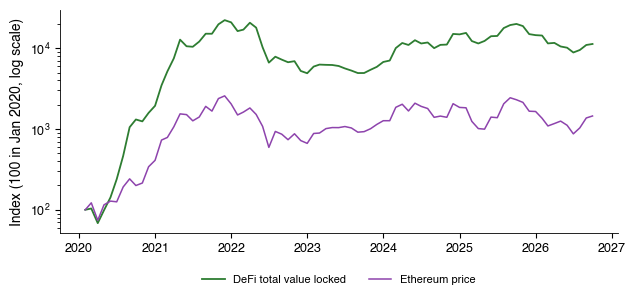

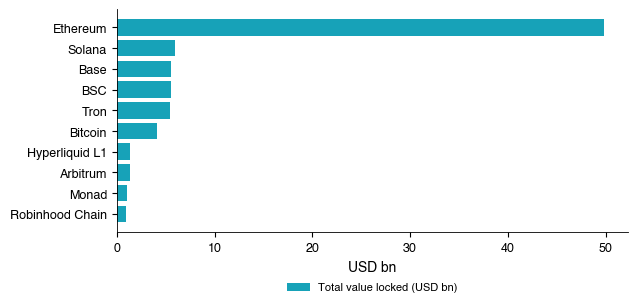

{'peak': 177.493346508,
 'peak_date': '2021-11-09',
 'last': np.float64(88.131011144),
 'last_date': '2026-09-18',
 'start': np.float64(0.606094144),
 'beta': np.float64(0.7894816040818687),
 'se': np.float64(0.06574994766366928),
 'r2': np.float64(0.6203903578259771),
 'n': 80,
 'corr': np.float64(0.7876486258643363),
 'chains': {'Ethereum': 49.8271445,
  'Solana': 5.897086928,
  'Base': 5.58137505,
  'BSC': 5.571916332,
  'Tron': 5.416886891,
  'Bitcoin': 4.128198215,
  'Hyperliquid L1': 1.374219286,
  'Arbitrum': 1.370825875,
  'Monad': 1.016079718,
  'Robinhood Chain': 0.956868696},
 'eth_share': np.float64(56.53758405039275),
 'chains_total': np.float64(88.131011144)}

In [14]:
def fig_defi_tvl():
    """TVL total (DefiLlama) si pretul Ethereum, lunar, 2020-2026; TVL pe blockchain-uri azi."""
    tvl = defi_tvl().loc['2020-01-01':]
    eth = price('ETH', '2020-01-01')
    m = pd.concat([tvl.resample('ME').last(), eth.resample('ME').last()], axis=1).dropna()
    m.columns = ['TVL', 'ETH']
    fig, ax = plt.subplots(figsize=(7.2, 2.9))
    ax.plot(m.index, 100 * m['TVL'] / m['TVL'].iloc[0], color=Forest, lw=1.3, label='DeFi total value locked')
    ax.plot(m.index, 100 * m['ETH'] / m['ETH'].iloc[0], color=Purple, lw=1.1, label='Ethereum price')
    ax.set_yscale('log')
    ax.set_ylabel('Index (100 in Jan 2020, log scale)')
    legend_outside_bottom(ax, ncol=2, y=-0.14)
    save_fig('ch16_defi_tvl')
    d = np.log(m).diff().dropna()
    reg = hac_ols(d['TVL'], d['ETH'], lags=3)
    # TVL pe blockchain-uri la aceeasi data ca seria totala (END): cele mai mari 10 dintre primele 15 de azi
    ch = pd.Series({c: chain_tvl_at(c, END) for c in chain_tvl().head(15).index}).sort_values(ascending=False).head(10)
    fig, ax = plt.subplots(figsize=(6.6, 2.9))
    ax.barh(ch.index[::-1], ch.values[::-1], color=Teal, label='Total value locked (USD bn)')
    ax.set_xlabel('USD bn')
    legend_outside_bottom(ax, ncol=1, y=-0.18)
    save_fig('ch16_tvl_chains')
    tot_now = tvl.iloc[-1]
    return dict(peak=tvl.max(), peak_date=str(tvl.idxmax().date()), last=tvl.iloc[-1], last_date=str(tvl.index[-1].date()),
                start=tvl.iloc[0], beta=reg.params['ETH'], se=reg.bse['ETH'], r2=reg.rsquared, n=len(d),
                corr=d['TVL'].corr(d['ETH']), chains={k: float(v) for k, v in ch.items()},
                eth_share=100 * ch.iloc[0] / tot_now, chains_total=tot_now)


fig_defi_tvl()

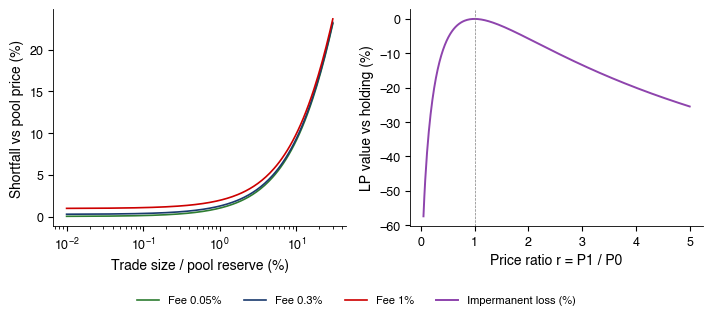

{'fee0.0005': {'0.001': 0.14980027462551115, '0.01': 1.0391140550200628, '0.05': 4.807257315650382, '0.1': 9.13223328333106}, 'fee0.003': {'0.001': 0.3993018960096739, '0.01': 1.284196560293871, '0.05': 5.034052483688145, '0.1': 9.338910611985074}, 'fee0.01': {'0.001': 1.0979130660646041, '0.01': 1.9704921279334653, '0.05': 5.669366364935691, '0.1': 9.91810737033667}, 'il': {'0.25': -19.999999999999996, '0.5': -5.719095841793653, '0.8': -0.6192010000093506, '1.25': -0.6192010000093395, '2': -5.719095841793653, '4': -19.999999999999996}}


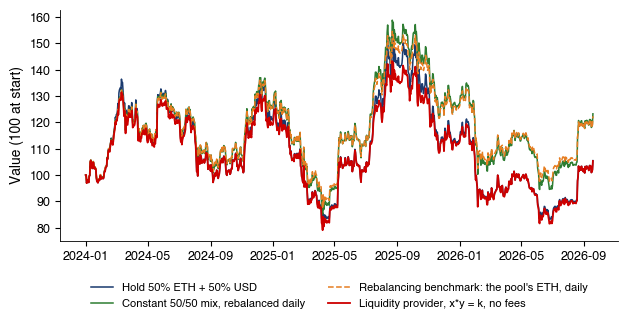

{'start': '2024-01-01',
 'p0': np.float64(2352.327940665),
 'p1': np.float64(2611.3471679688),
 'ratio': np.float64(1.110111869534048),
 'hodl': np.float64(105.50559347670242),
 'lp': np.float64(105.3618464879032),
 'reb': np.float64(123.27143266781309),
 'mmrz': np.float64(122.35348565854297),
 'lvr_level': np.float64(16.991639170639772),
 'il': np.float64(-0.13624584636924286),
 'sigma': np.float64(68.05867468075657),
 'lvr_theory': 5.78997899912632,
 'lvr_real': np.float64(5.826548448027627),
 'cm_gap': np.float64(5.786065338541193),
 'years': 2.7132101300479126,
 'fee_apr_hodl': np.float64(0.050249976550993995)}

In [15]:
def amm_swap(x, y, dx, fee=0.003):
    """Schimb dx din activul X intr-un fond x*y = k cu comision fee: cantitatea primita si pretul efectiv."""
    g = 1 - fee
    dy = y * g * dx / (x + g * dx)
    return dy, dy / dx


def impermanent_loss(r):
    """Pierderea impermanenta a unui furnizor de lichiditate 50/50 x*y = k, pentru raportul de pret r = P1/P0."""
    return 2 * np.sqrt(r) / (1 + r) - 1


def fig_amm_theory():
    """Alunecarea pretului in functie de marimea ordinului si pierderea impermanenta."""
    delta = np.logspace(-4, np.log10(0.3), 200)
    fig, axes = plt.subplots(1, 2, figsize=(7.2, 2.9))
    out = {}
    for fee, c in [(0.0005, Forest), (0.003, MainBlue), (0.01, IDAred)]:
        g = 1 - fee
        slip = 100 * (1 - g / (1 + g * delta))
        axes[0].plot(100 * delta, slip, color=c, lw=1.2, label=f'Fee {100 * fee:g}%')
        out[f'fee{fee}'] = {f'{d:g}': float(100 * (1 - g / (1 + g * d))) for d in [0.001, 0.01, 0.05, 0.1]}
    axes[0].set_xscale('log')
    axes[0].set_xlabel('Trade size / pool reserve (%)')
    axes[0].set_ylabel('Shortfall vs pool price (%)')
    rr = np.linspace(0.05, 5, 300)
    axes[1].plot(rr, 100 * impermanent_loss(rr), color=Purple, lw=1.4, label='Impermanent loss (%)')
    axes[1].axvline(1, color=Gray, lw=0.5, ls='--')
    axes[1].set_xlabel('Price ratio r = P1 / P0')
    axes[1].set_ylabel('LP value vs holding (%)')
    fig.tight_layout()
    fig_legend_bottom(fig, ncol=4, y=0.0)
    save_fig('ch16_amm_theory')
    out['il'] = {f'{r:g}': float(100 * impermanent_loss(r)) for r in [0.25, 0.5, 0.8, 1.25, 2, 4]}
    return out


def fig_lp_vs_hodl(start='2024-01-01'):
    """Fond ETH/USD x*y = k fara comisioane: furnizorul de lichiditate vs pastrarea activelor, vs portofoliul de
    reechilibrare din Milionis et al. (2022) (detine in fiecare zi cantitatea de ETH a fondului, x = V/(2P), si
    tranzactioneaza la pretul pietei) si vs un portofoliu 50/50 reechilibrat zilnic (pondere constanta)."""
    p = price('ETH', start)
    rel = p / p.iloc[0]
    hodl = 100 * (1 + rel) / 2
    lp = 100 * np.sqrt(rel)
    R = p.pct_change().fillna(0)
    reb = 100 * (1 + 0.5 * R).cumprod()
    x_pool = lp / (2 * p)                                         # ETH detinut de fond (V'(P) = V / 2P)
    dR = (x_pool.shift(1) * p.diff()).fillna(0)
    mmrz = 100 + dR.cumsum()                                      # R_t = R_(t-1) + x(P_(t-1)) (P_t - P_(t-1))
    fig, ax = plt.subplots(figsize=(7.2, 3.0))
    ax.plot(hodl.index, hodl.values, color=MainBlue, lw=1.1, label='Hold 50% ETH + 50% USD')
    ax.plot(reb.index, reb.values, color=Forest, lw=1.1, label='Constant 50/50 mix, rebalanced daily')
    ax.plot(mmrz.index, mmrz.values, color=Orange, lw=1.1, ls='--', label="Rebalancing benchmark: the pool's ETH, daily")
    ax.plot(lp.index, lp.values, color=IDAred, lw=1.3, label='Liquidity provider, x*y = k, no fees')
    ax.set_ylabel('Value (100 at start)')
    legend_outside_bottom(ax, ncol=2, y=-0.14)
    save_fig('ch16_lp_vs_hodl')
    r = np.log(p).diff().dropna()
    sig2 = r.var() * 365
    yrs = (p.index[-1] - p.index[0]).days / 365.25
    # LVR realizata (Milionis et al., 2022): suma pierderilor zilnice (dR_t - dV_t) / V_(t-1), anualizata
    lvr_real = ((dR - lp.diff()) / lp.shift(1)).dropna().sum() / yrs
    return dict(start=str(p.index[0].date()), p0=p.iloc[0], p1=p.iloc[-1], ratio=rel.iloc[-1], hodl=hodl.iloc[-1],
                lp=lp.iloc[-1], reb=reb.iloc[-1], mmrz=mmrz.iloc[-1], lvr_level=mmrz.iloc[-1] - lp.iloc[-1],
                il=100 * (lp.iloc[-1] / hodl.iloc[-1] - 1), sigma=100 * np.sqrt(sig2),
                lvr_theory=100 * sig2 / 8, lvr_real=100 * lvr_real, cm_gap=100 * np.log(reb.iloc[-1] / lp.iloc[-1]) / yrs,
                years=yrs, fee_apr_hodl=100 * np.log(hodl.iloc[-1] / lp.iloc[-1]) / yrs)


print(fig_amm_theory())
fig_lp_vs_hodl()

## 7. Spot ETFs and crypto equities

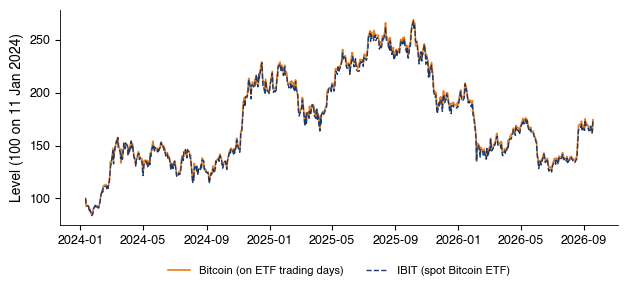

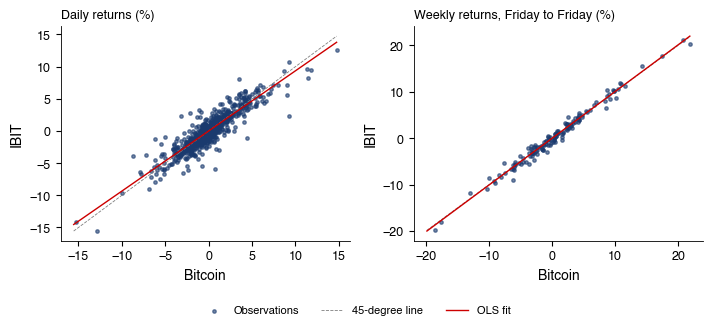

,ibit,etha
start,2024-01-11,2024-07-23
n_d,673,541
n_w,140,112
beta_d,0.934804,0.938312
r2_d,0.824884,0.826042
beta_d_next,0.036581,0.012422
beta_d_same,0.936389,0.937121
r2_d_two,0.824847,0.825407
beta_w,1.007122,0.985703
se_w,0.011341,0.017147


In [16]:
def etf_tracking(etf='IBIT', coin='BTC'):
    """Randamente ETF vs activ suport in zilele de tranzactionare ale ETF-ului: zilnic (aceeasi data si data urmatoare)
    si saptamanal (vineri); abaterea de urmarire; deriva raportului ETF / activ (comisionul anual)."""
    p = joint_prices([etf, coin])
    r = np.log(p).diff().dropna()
    c_next = np.log(price(coin)).diff().shift(-1).reindex(r.index)
    d_same = hac_ols(r[etf], r[coin])
    xx = pd.concat([r[coin], c_next.rename('next')], axis=1).dropna()
    d_two = hac_ols(r[etf].reindex(xx.index), xx)
    w = joint_returns([etf, coin], freq='W')
    wk = hac_ols(w[etf], w[coin])
    te_d = 100 * (r[etf] - r[coin]).std() * np.sqrt(252)
    te_w = 100 * (w[etf] - w[coin]).std() * np.sqrt(52)
    lr = np.log(p[etf] / p[coin])
    t = (lr.index - lr.index[0]).days / 365.25
    drift = np.polyfit(t, lr.values, 1)[0]
    vol = read_market(ASSETS[etf][0])
    dv = (vol['close'] * vol['volume']).loc[:END] / 1e9
    return dict(start=str(p.index[0].date()), n_d=len(r), n_w=len(w), beta_d=d_same.params[coin], r2_d=d_same.rsquared,
                beta_d_next=d_two.params['next'], beta_d_same=d_two.params[coin], r2_d_two=d_two.rsquared,
                beta_w=wk.params[coin], se_w=wk.bse[coin], r2_w=wk.rsquared, te_d=te_d, te_w=te_w,
                drift=100 * drift, corr_next=r[etf].corr(c_next), dv_mean=dv.mean(), dv_last60=dv.iloc[-60:].mean(),
                dv_max=dv.max(), dv_max_date=str(dv.idxmax().date()))


def fig_etf():
    """IBIT si Bitcoin: nivelurile normalizate si randamentele zilnice vs saptamanale."""
    p = joint_prices(['IBIT', 'BTC'])
    n = 100 * p / p.iloc[0]
    fig, ax = plt.subplots(figsize=(7.2, 2.8))
    ax.plot(n.index, n['BTC'], color=Orange, lw=1.2, label='Bitcoin (on ETF trading days)')
    ax.plot(n.index, n['IBIT'], color=MainBlue, lw=1.0, ls='--', label='IBIT (spot Bitcoin ETF)')
    ax.set_ylabel('Level (100 on 11 Jan 2024)')
    legend_outside_bottom(ax, ncol=2, y=-0.14)
    save_fig('ch16_etf_tracking')
    r = np.log(p).diff().dropna() * 100
    w = joint_returns(['IBIT', 'BTC'], freq='W') * 100
    fig, axes = plt.subplots(1, 2, figsize=(7.2, 3.0))
    for ax, x, lab in [(axes[0], r, 'Daily returns (%)'), (axes[1], w, 'Weekly returns, Friday to Friday (%)')]:
        ax.scatter(x['BTC'], x['IBIT'], s=6, color=MainBlue, alpha=0.6, label='Observations')
        lim = [min(x.min()), max(x.max())]
        ax.plot(lim, lim, color=Gray, lw=0.6, ls='--', label='45-degree line')
        b = np.polyfit(x['BTC'], x['IBIT'], 1)
        ax.plot(lim, np.polyval(b, lim), color=IDAred, lw=1.0, label='OLS fit')
        ax.set_xlabel('Bitcoin')
        ax.set_ylabel('IBIT')
        ax.set_title(lab, fontsize=9, loc='left')
    fig.tight_layout()
    fig_legend_bottom(fig, ncol=3, y=0.0)
    save_fig('ch16_etf_timing')
    return dict(ibit=etf_tracking('IBIT', 'BTC'), etha=etf_tracking('ETHA', 'ETH'),
                ibit_end=n['IBIT'].iloc[-1], btc_end=n['BTC'].iloc[-1])


etf = fig_etf()
pd.DataFrame({k: etf[k] for k in ['ibit', 'etha']}).round(3)

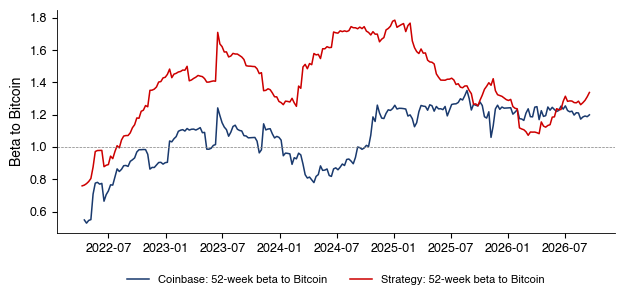

{'COIN': {'n': 283,
  'a': np.float64(-37.1076394972931),
  'b_btc': np.float64(0.7910266844934069),
  'se_btc': np.float64(0.08866809352388204),
  'b_spx': np.float64(2.052364275536415),
  'se_spx': np.float64(0.22120064234878067),
  'r2': np.float64(0.5150423663570067),
  'b1': np.float64(0.9471280007414183),
  'r2_1': np.float64(0.3773906614310575),
  'vol': np.float64(84.2438897657084),
  'beta_last': np.float64(1.1991328215119865),
  'beta_min': 0.5284704945617862,
  'beta_max': 1.350240314556642,
  'corr': np.float64(0.6143213014628897)},
 'MSTR': {'n': 284,
  'a': np.float64(-4.513010727188793),
  'b_btc': np.float64(1.1790462926504703),
  'se_btc': np.float64(0.10906314033889425),
  'b_spx': np.float64(1.0237323842127528),
  'se_spx': np.float64(0.24077911294751544),
  'r2': np.float64(0.6296820667195857),
  'b1': np.float64(1.2571629283519503),
  'r2_1': np.float64(0.5988774326110564),
  'vol': np.float64(88.69052432912956),
  'beta_last': np.float64(1.3376273702589119),
  'be

In [17]:
def fig_crypto_equities(start='2021-04-16'):
    """Regresii saptamanale cu doi factori (Bitcoin, S&P 500) si beta mobil pe 52 de saptamani fata de Bitcoin."""
    out = {}
    fig, ax = plt.subplots(figsize=(7.2, 2.9))
    for k in ['COIN', 'MSTR']:
        w = joint_returns([k, 'BTC', 'SPX'], start, freq='W')
        m = hac_ols(w[k], w[['BTC', 'SPX']])
        m1 = hac_ols(w[k], w['BTC'])
        cov = w[k].rolling(52).cov(w['BTC'])
        beta = (cov / w['BTC'].rolling(52).var()).dropna()
        ax.plot(beta.index, beta.values, color=COL[k], lw=1.1, label=f'{LABELS[k]}: 52-week beta to Bitcoin')
        out[k] = dict(n=len(w), a=52 * 100 * m.params['const'], b_btc=m.params['BTC'], se_btc=m.bse['BTC'],
                      b_spx=m.params['SPX'], se_spx=m.bse['SPX'], r2=m.rsquared, b1=m1.params['BTC'], r2_1=m1.rsquared,
                      vol=100 * w[k].std() * np.sqrt(52), beta_last=beta.iloc[-1], beta_min=beta.min(),
                      beta_max=beta.max(), corr=w[k].corr(w['BTC']))
    ax.axhline(1, color=Gray, lw=0.5, ls='--')
    ax.set_ylabel('Beta to Bitcoin')
    legend_outside_bottom(ax, ncol=2, y=-0.14)
    save_fig('ch16_crypto_equities')
    wb = joint_returns(['BTC', 'SPX'], start, freq='W')
    out['btc_vol'] = 100 * wb['BTC'].std() * np.sqrt(52)
    return out


fig_crypto_equities()

## 8. Are cryptos becoming alternative assets?

- Tail, memory and moment features of 26 assets in two windows; principal components; distances between class centroids.

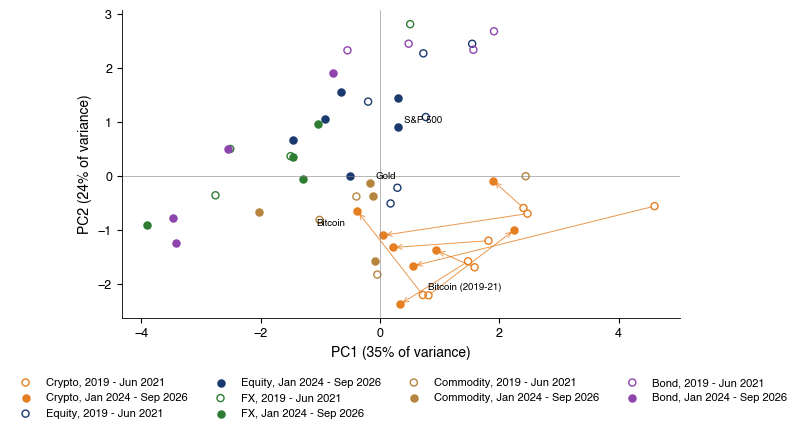

{'ev1': np.float64(34.890637857384085),
 'ev2': np.float64(24.356269632257067),
 'loadings': {'ann_vol': 0.43599343849678973,
  'skew': 0.13570351556372814,
  'kurt': 0.5164730253622505,
  'acf1': -0.046835224117058545,
  'acf1_sq': 0.07944382469180297,
  'hill_left': -0.47672939246587587,
  'hill_right': -0.33800261142376964,
  'mdd': -0.4180052069707118},
 'W1': {'dist_equity': 3.026268739604914,
  'dist_commodity': 2.2620342454943065,
  'dist_fx': 4.2476990154113885,
  'dist_bond': 4.326436872324231,
  'spread_crypto': 2.127894792768567,
  'btc_vol': 76.9421239103302,
  'crypto_kurt': 16.927262706295515},
 'W2': {'dist_equity': 2.632580686516067,
  'dist_commodity': 1.8568852270601266,
  'dist_fx': 3.3573944504644215,
  'dist_bond': 3.7064469734826155,
  'spread_crypto': 1.426165841980473,
  'btc_vol': 47.429186944092486,
  'crypto_kurt': 4.019071649713214}}

In [18]:
WINDOWS = {'W1': ('2019-01-01', '2021-06-30'), 'W2': ('2024-01-11', '2026-09-18')}
FEATURES = ['ann_vol', 'skew', 'kurt', 'acf1', 'acf1_sq', 'hill_left', 'hill_right', 'mdd']


def asset_features(r, ppy=None):
    """Caracteristicile statistice ale unei serii de randamente log zilnice (ppy: observatii pe an, implicit
    frecventa reala a seriei)."""
    ppy = periods_per_year(r) if ppy is None else ppy
    p = np.exp(r.cumsum())
    return dict(ann_vol=np.log(r.std() * np.sqrt(ppy)), skew=stats.skew(r), kurt=np.log1p(max(stats.kurtosis(r), 0)),
                acf1=r.autocorr(1), acf1_sq=(r ** 2).autocorr(1), hill_left=hill(-r.values - (-r).median()),
                hill_right=hill(r.values - r.median()), mdd=(p / p.cummax() - 1).min())


def feature_table():
    """Tabelul caracteristicilor pe active si ferestre (W1: 2019 - iunie 2021; W2: era ETF-urilor spot)."""
    rows = []
    for s, (lab, cls, _) in CLASS_ASSETS.items():
        for w, (a, b) in WINDOWS.items():
            r = symbol_returns(s, a, b)
            rows.append(dict(symbol=s, label=lab, cls=cls, window=w, **asset_features(r)))
    return pd.DataFrame(rows)


def fig_alt_assets():
    """Componente principale ale caracteristicilor standardizate; distanta cripto - clasele traditionale."""
    f = feature_table()
    X = f[FEATURES].values
    Z = (X - X.mean(0)) / X.std(0)
    U, S, Vt = np.linalg.svd(Z, full_matrices=False)
    pc = Z @ Vt[:2].T
    if np.corrcoef(pc[:, 0], f['ann_vol'])[0, 1] < 0:
        pc[:, 0] *= -1
        Vt[0] *= -1          # incarcarile PC1 cu acelasi semn ca axa din grafic
    f['pc1'], f['pc2'] = pc[:, 0], pc[:, 1]
    ev = S ** 2 / (S ** 2).sum()
    fig, ax = plt.subplots(figsize=(7.2, 4.0))
    for cls, c in CLASS_COL.items():
        for w, mk, fc in [('W1', 'o', 'none'), ('W2', 'o', c)]:
            x = f[(f.cls == cls) & (f.window == w)]
            ax.scatter(x['pc1'], x['pc2'], s=26, marker=mk, facecolors=fc, edgecolors=c, lw=1.0,
                       label=f'{cls}, ' + ('2019 - Jun 2021' if w == 'W1' else 'Jan 2024 - Sep 2026'))
    for s in f[f.cls == 'Crypto'].symbol.unique():
        a = f[(f.symbol == s) & (f.window == 'W1')].iloc[0]
        b = f[(f.symbol == s) & (f.window == 'W2')].iloc[0]
        ax.annotate('', xy=(b.pc1, b.pc2), xytext=(a.pc1, a.pc2),
                    arrowprops=dict(arrowstyle='->', color=Orange, lw=0.7, alpha=0.8))
    for s, w, dx, dy in [('BTC-USD.CC', 'W1', 4, 4), ('BTC-USD.CC', 'W2', -30, -10), ('GSPC.INDX', 'W2', 4, 3),
                         ('XAUUSD.FOREX', 'W2', 4, 3)]:
        b = f[(f.symbol == s) & (f.window == w)].iloc[0]
        lab = b.label + (' (2019-21)' if w == 'W1' else '')
        ax.annotate(lab, (b.pc1, b.pc2), xytext=(dx, dy), textcoords='offset points', fontsize=7, color='black')
    ax.axhline(0, color=Gray, lw=0.4)
    ax.axvline(0, color=Gray, lw=0.4)
    ax.set_xlabel(f'PC1 ({100 * ev[0]:.0f}% of variance)')
    ax.set_ylabel(f'PC2 ({100 * ev[1]:.0f}% of variance)')
    legend_outside_bottom(ax, ncol=4, y=-0.16)
    save_fig('ch16_alt_assets')
    # distante in spatiul complet standardizat
    f[[f'z_{c}' for c in FEATURES]] = Z
    zc = [f'z_{c}' for c in FEATURES]
    out = dict(ev1=100 * ev[0], ev2=100 * ev[1], loadings={c: float(v) for c, v in zip(FEATURES, Vt[0])})
    for w in WINDOWS:
        g = f[f.window == w]
        cen = g.groupby('cls')[zc].mean()
        cr = g[g.cls == 'Crypto'][zc].values
        out[w] = dict(dist_equity=float(np.linalg.norm(cen.loc['Crypto'] - cen.loc['Equity'])),
                      dist_commodity=float(np.linalg.norm(cen.loc['Crypto'] - cen.loc['Commodity'])),
                      dist_fx=float(np.linalg.norm(cen.loc['Crypto'] - cen.loc['FX'])),
                      dist_bond=float(np.linalg.norm(cen.loc['Crypto'] - cen.loc['Bond'])),
                      spread_crypto=float(np.mean(np.linalg.norm(cr - cr.mean(0), axis=1))),
                      btc_vol=float(np.exp(g[g.symbol == 'BTC-USD.CC']['ann_vol'].iloc[0]) * 100),
                      crypto_kurt=float(np.expm1(g[g.cls == 'Crypto']['kurt']).median()))
    f.drop(columns=zc).to_csv(os.path.join(HERE, 'ch16_asset_features.csv'), index=False)
    return out


fig_alt_assets()

## 9. Inference

- Hill standard errors and CIs; $\sup$-Wald break test and Forbes–Rigobon correlation; threshold AR for the pegs with Hansen's bootstrap; LVR interval; block bootstrap of the asset-class map; GRS and Fama–MacBeth with Shanken errors; Dimson betas.

In [19]:
TRIM = 0.15
COINS = ['BTC', 'ETH', 'XRP', 'BNB', 'ADA', 'DOGE', 'LTC', 'LINK']


def hill_k(x, k):
    """Estimatorul Hill din cele mai mari k valori pozitive ale lui x."""
    x = np.sort(x[x > 0])[::-1]
    return 1 / np.mean(np.log(x[:k] / x[k]))


def hill_inference(start='2018-01-01', B=1000, block=20):
    """alpha_H din cele mai mari 5% pierderi, eroarea standard asimptotica alpha/sqrt(k) (date i.i.d.),
    CI 95%, CI bootstrap pe blocuri mobile (dependenta), si alpha pentru k = 2.5% si 10%."""
    rng = np.random.default_rng(SEED)
    out = {}
    for key in STYL:
        r = 100 * np.log(price(key, start)).diff().dropna().values
        L = -r
        nl = int((L > 0).sum())
        k = max(int(0.05 * nl), 10)
        a = hill(L)
        se = a / np.sqrt(k)
        n = len(r)
        nb = int(np.ceil(n / block))
        bs = []
        for _ in range(B):
            st = rng.integers(0, n - block + 1, nb)
            y = r[(st[:, None] + np.arange(block)[None, :]).ravel()[:n]]
            bs.append(hill(-y))
        out[key] = dict(alpha=a, k=k, n_loss=nl, se=se, lo=a - 1.96 * se, hi=a + 1.96 * se,
                        b_lo=float(np.percentile(bs, 2.5)), b_hi=float(np.percentile(bs, 97.5)), b_se=float(np.std(bs)),
                        a25=hill_k(L, max(int(0.025 * nl), 10)), a10=hill_k(L, int(0.10 * nl)))
    for a, b in [('BTC', 'SPX'), ('BTC', 'GOLD'), ('DOGE', 'SPX')]:
        d = out[a]['alpha'] - out[b]['alpha']
        out[f'z_{a}_{b}'] = d / np.sqrt(out[a]['se'] ** 2 + out[b]['se'] ** 2)
    out['alpha_min'] = min(out[k]['alpha'] for k in STYL)
    out['alpha_max'] = max(out[k]['alpha'] for k in STYL)
    out['hi_max'] = max(out[k]['hi'] for k in STYL)
    return out


def nw_lags(T):
    """Numarul de decalaje Newey-West: floor(4 (T/100)^(2/9))."""
    return int(np.floor(4 * (T / 100) ** (2 / 9)))


def hac_meat(Z, u, L):
    """Matricea de varianta pe termen lung a lui z_t u_t, nucleu Bartlett cu L decalaje."""
    g = Z * u[:, None]
    S = g.T @ g
    for l in range(1, L + 1):
        G = g[l:].T @ g[:-l]
        S += (1 - l / (L + 1)) * (G + G.T)
    return S


def sup_wald_crit(p, trim=TRIM, reps=20000, grid=1000, seed=SEED):
    """Distributia asimptotica sub H0 a sup-Wald (Andrews, 1993): sup ||B(r) - r B(1)||^2 / (r (1 - r)),
    B miscare browniana p-dimensionala, r in [trim, 1 - trim]; simulare."""
    rng = np.random.default_rng(seed)
    r = np.arange(1, grid + 1) / grid
    sel = (r >= trim) & (r <= 1 - trim)
    out = np.empty(reps)
    for i in range(reps):
        W = np.cumsum(rng.standard_normal((grid, p)), axis=0) / np.sqrt(grid)
        BB = W - r[:, None] * W[-1]
        out[i] = np.max((BB[sel] ** 2).sum(axis=1) / (r[sel] * (1 - r[sel])))
    return out


def sup_wald(y, X, index, trim=TRIM, lags=None):
    """Test sup-Wald pentru o ruptura in toti coeficientii lui y = X b + u la o data necunoscuta, cu matrice de
    covarianta HAC (Bartlett) calculata separat in fiecare regim; data estimata = minimul SSR (Bai, 1997)."""
    y, X = np.asarray(y, float), np.asarray(X, float)
    T, p = X.shape
    L = nw_lags(T) if lags is None else lags
    lo, hi = int(np.floor(trim * T)), int(np.ceil((1 - trim) * T))
    W, SSR = np.full(T, np.nan), np.full(T, np.nan)
    for tb in range(lo, hi):
        res = []
        V = np.zeros((p, p))
        ssr = 0.0
        for a, b in [(0, tb), (tb, T)]:
            Xa, ya = X[a:b], y[a:b]
            XtX = Xa.T @ Xa
            bet = np.linalg.solve(XtX, Xa.T @ ya)
            u = ya - Xa @ bet
            ssr += u @ u
            Q = np.linalg.inv(XtX)
            V += Q @ hac_meat(Xa, u, L) @ Q
            res.append(bet)
        d = res[1] - res[0]
        W[tb] = d @ np.linalg.solve(V, d)
        SSR[tb] = ssr
    tb_w = int(np.nanargmax(W))
    tb_hat = int(np.nanargmin(SSR))
    # CI Bai (1997): (d'Q d)^2 / (d'Omega d) (T_hat - T0) -> argmax(W(s) - |s|/2); 97.5% cuantila = 11
    b0 = np.linalg.lstsq(X[:tb_hat], y[:tb_hat], rcond=None)[0]
    b1 = np.linalg.lstsq(X[tb_hat:], y[tb_hat:], rcond=None)[0]
    d = b1 - b0
    u = y - np.where(np.arange(T)[:, None] < tb_hat, X @ b0[:, None], X @ b1[:, None]).ravel()
    Qm = X.T @ X / T
    Om = hac_meat(X, u, L) / T
    Lm = (d @ Qm @ d) ** 2 / (d @ Om @ d)
    half = int(np.ceil(11 / Lm)) + 1
    idx = pd.DatetimeIndex(index)
    return dict(sup_w=float(np.nanmax(W)), date_w=str(idx[tb_w].date()), date=str(idx[tb_hat].date()),
                ci_lo=str(idx[max(tb_hat - half, 0)].date()), ci_hi=str(idx[min(tb_hat + half, T - 1)].date()),
                half=half, b_pre=b0.tolist(), b_post=b1.tolist(), T=T, lags=L, W=W)


def break_btc_spx(start='2016-01-01'):
    """Ruptura in regresia r_BTC = a + b r_SPX + u (zile comune, randamente log zilnice); corelatiile inainte /
    dupa data estimata; corelatia ajustata Forbes-Rigobon relativ la 2017-2019."""
    r = 100 * joint_returns(['BTC', 'SPX'], start)
    X = np.column_stack([np.ones(len(r)), r['SPX'].values])
    sw = sup_wald(r['BTC'].values, X, r.index)
    crit = sup_wald_crit(2)
    sw['p'] = float((crit >= sw['sup_w']).mean())
    sw['cv5'] = float(np.percentile(crit, 95))
    sw['cv1'] = float(np.percentile(crit, 99))
    W = pd.Series(sw.pop('W'), index=r.index)
    sw['W_etf'] = float(W.loc[ETF_START:].iloc[0])
    sw['W_date'] = float(W.loc[sw['date']])
    sw['start'] = str(r.index[0].date())
    pre, post = r.loc[:sw['date']].iloc[:-1], r.loc[sw['date']:]
    sw['rho_pre'], sw['rho_post'] = pre['BTC'].corr(pre['SPX']), post['BTC'].corr(post['SPX'])
    # Forbes-Rigobon: rho* = rho / sqrt(1 + delta (1 - rho^2)), delta = var_high / var_low - 1 (piata sursa: S&P 500)
    per = {'p1': ('2017-01-01', '2019-12-31'), 'p2': ('2020-01-01', '2023-12-31'), 'p3': (ETF_START, END)}
    x = {k: r.loc[a:b] for k, (a, b) in per.items()}
    fr = {}
    for k in per:
        rho = x[k]['BTC'].corr(x[k]['SPX'])
        delta = x[k]['SPX'].var() / x['p1']['SPX'].var() - 1
        fr[k] = dict(rho=rho, delta=delta, rho_star=rho / np.sqrt(1 + delta * (1 - rho ** 2)), n=len(x[k]),
                     vol_spx=x[k]['SPX'].std() * np.sqrt(252))
    # bootstrap pe blocuri pentru rho*_p2 - rho_p1 (fiecare perioada reesantionata separat)
    rng = np.random.default_rng(SEED)
    def cbb(z):
        n = len(z)
        nb = int(np.ceil(n / 20))
        st = rng.integers(0, n - 19, nb)
        return z[(st[:, None] + np.arange(20)[None, :]).ravel()[:n]]
    a1, a2 = x['p1'].values, x['p2'].values
    dd = []
    for _ in range(2000):
        z1, z2 = cbb(a1), cbb(a2)
        r1 = np.corrcoef(z1.T)[0, 1]
        r2 = np.corrcoef(z2.T)[0, 1]
        dl = z2[:, 1].var() / z1[:, 1].var() - 1
        dd.append(r2 / np.sqrt(1 + dl * (1 - r2 ** 2)) - r1)
    fr['diff'] = fr['p2']['rho_star'] - fr['p1']['rho']
    fr['diff_lo'], fr['diff_hi'] = np.percentile(dd, [2.5, 97.5])
    sw['fr'] = fr
    return sw


print(pd.DataFrame({k: v for k, v in hill_inference().items() if isinstance(v, dict)}).round(2))
brk = break_btc_spx()
{k: v for k, v in brk.items() if k != 'fr'}, brk['fr']

            BTC      ETH      SOL     DOGE     SPX     GOLD
alpha      2.73     2.67     2.85     2.83    2.87     2.75
k         78.00    78.00    59.00    82.00   49.00    50.00
n_loss  1561.00  1560.00  1183.00  1645.00  994.00  1019.00
se         0.31     0.30     0.37     0.31    0.41     0.39
lo         2.12     2.08     2.12     2.22    2.07     1.99
hi         3.33     3.26     3.58     3.45    3.67     3.51
b_lo       2.35     2.37     2.21     2.30    2.15     2.22
b_hi       3.42     3.33     3.71     3.64    4.48     3.88
b_se       0.27     0.25     0.39     0.35    0.61     0.43
a25        3.48     3.73     2.61     2.49    3.13     3.32
a10        2.59     2.61     2.76     2.44    2.34     2.68


({'sup_w': 20.212027907562355,
  'date_w': '2017-08-14',
  'date': '2020-03-09',
  'ci_lo': '2018-11-27',
  'ci_hi': '2021-06-15',
  'half': 320,
  'b_pre': [0.2882281938667576, 0.0721138341979849],
  'b_post': [0.06285215844018131, 1.2168782902407151],
  'T': 2692,
  'lags': 8,
  'p': 0.0008,
  'cv5': 11.550454135618308,
  'cv1': 15.176454648356577,
  'W_etf': 2.3149010493711657,
  'W_date': 18.805500410064422,
  'start': '2016-01-04',
  'rho_pre': np.float64(0.013637823596681118),
  'rho_post': np.float64(0.4004860774578464)},
 {'p1': {'rho': np.float64(0.022891398561799222),
   'delta': 0.0,
   'rho_star': np.float64(0.022891398561799222),
   'n': 753,
   'vol_spx': np.float64(12.839865894772798)},
  'p2': {'rho': np.float64(0.3915765252495029),
   'delta': 2.2386537148161416,
   'rho_star': np.float64(0.23012439399595971),
   'n': 1006,
   'vol_spx': np.float64(23.106956411348587)},
  'p3': {'rho': np.float64(0.3838564622095312),
   'delta': 0.41703308988091337,
   'rho_star': np.f

In [20]:
def tar_fit(d, trim=TRIM, B=999, seed=SEED):
    """EQ-TAR: d_t = phi_in d_{t-1} + e_t daca |d_{t-1}| <= c, d_t = phi_out d_{t-1} + e_t altfel.
    Pragul c: cautare pe grila (valorile lui |d_{t-1}| intre cuantilele trim si 1 - trim), minimul SSR.
    Test H0: phi_in = phi_out (AR(1) liniar), sup-Wald robust la heteroscedasticitate; p-valoare prin bootstrap cu
    regresori ficsi y*_t = e_t eta_t, eta_t ~ N(0, 1), e_t reziduurile modelului liniar (H0) (Hansen, 1996).
    Doar perechile (d_(t-1), d_t) din zile calendaristice consecutive: daca se elimina o perioada din serie, nicio
    pereche nu trece peste golul creat."""
    ok = np.diff(d.index.values).astype('timedelta64[D]') == np.timedelta64(1, 'D')
    y, x = d.values[1:][ok], d.values[:-1][ok]
    a = np.abs(x)
    order = np.argsort(a, kind='stable')
    xs, ys, as_ = x[order], y[order], a[order]
    n = len(y)
    x2 = xs ** 2
    lo, hi = int(np.floor(trim * n)), int(np.ceil((1 - trim) * n))
    # pozitiile unde se poate taia (valori distincte ale lui |x|)
    cuts = np.array([i for i in range(lo, hi) if as_[i] < as_[i + 1]]) + 1   # regimul interior = primele i observatii

    def wald(yy):
        c1 = np.cumsum(xs * yy)
        c2 = np.cumsum(x2)
        c3 = np.cumsum(x2 * yy ** 2)
        c4 = np.cumsum(xs ** 3 * yy)
        c5 = np.cumsum(xs ** 4)
        T1, T2, T3, T4, T5 = c1[-1], c2[-1], c3[-1], c4[-1], c5[-1]
        i = cuts - 1
        Sin, Sout = c2[i], T2 - c2[i]
        pin, pout = c1[i] / Sin, (T1 - c1[i]) / Sout
        vin = (c3[i] - 2 * pin * c4[i] + pin ** 2 * c5[i]) / Sin ** 2
        vout = ((T3 - c3[i]) - 2 * pout * (T4 - c4[i]) + pout ** 2 * (T5 - c5[i])) / Sout ** 2
        return (pin - pout) ** 2 / (vin + vout), pin, pout, vin, vout

    Wc, pin, pout, vin, vout = wald(ys)
    # estimarea pragului: minimul SSR
    c1 = np.cumsum(xs * ys)
    c2 = np.cumsum(x2)
    i = cuts - 1
    ssr = np.sum(ys ** 2) - c1[i] ** 2 / c2[i] - (c1[-1] - c1[i]) ** 2 / (c2[-1] - c2[i])
    j = int(np.argmin(ssr))
    phi_lin = np.sum(x * y) / np.sum(x ** 2)
    e0 = ys - phi_lin * xs
    rng = np.random.default_rng(seed)
    sup0 = Wc.max()
    bs = np.array([wald(e0 * rng.standard_normal(n))[0].max() for _ in range(B)])
    hl = lambda p: float(np.log(0.5) / np.log(abs(p))) if 0 < abs(p) < 1 else None
    nin = int(cuts[j])
    return dict(n=n, c=float(as_[cuts[j] - 1]), n_in=nin, n_out=n - nin, share_out=100 * (n - nin) / n,
                phi_in=float(pin[j]), se_in=float(np.sqrt(vin[j])), phi_out=float(pout[j]), se_out=float(np.sqrt(vout[j])),
                hl_in=hl(pin[j]), hl_out=hl(pout[j]), phi_lin=float(phi_lin), hl_lin=hl(phi_lin),
                sup_w=float(sup0), p_boot=float((1 + (bs >= sup0).sum()) / (B + 1)), B=B,
                chi2_p=float(stats.chi2.sf(sup0, 1)), c_grid=[float(as_[cuts[0] - 1]), float(as_[cuts[-1] - 1])],
                share_var_out=float(100 * np.sum(x2[nin:]) / np.sum(x2)))


def peg_tar(start='2021-01-01'):
    """EQ-TAR pentru USDT, USDC, DAI: abaterea inchiderii zilnice in puncte de baza, 2021-2026."""
    out = {}
    for k in STABLE:
        d = 1e4 * (read_market(ASSETS[k][0]).loc[start:END, 'close'] - 1)
        out[k] = tar_fit(d)
    return out


def lvr_ci(start='2024-01-01', B=2000, block=20, seed=SEED):
    """Rata anuala LVR realizata (Milionis et al., 2022): portofoliul de reechilibrare detine zilnic cantitatea de ETH
    a fondului x = V/(2P); pierderea zilnica normalizata (dR_t - dV_t)/V_(t-1) = R_t/2 - (sqrt(1 + R_t) - 1),
    R_t randamentul simplu; rata = suma / ani. sigma^2/8 din varianta randamentelor log; rv8 = suma R_t^2 / 8 / ani;
    interval bootstrap pe blocuri mobile pentru rata realizata, pentru sigma^2/8 si pentru diferenta."""
    p = price('ETH', start)
    r = np.log(p).diff().dropna().values
    yrs = (p.index[-1] - p.index[0]).days / 365.25

    def rates(rr):
        R = np.expm1(rr)
        real = np.sum(R / 2 - (np.sqrt(1 + R) - 1)) / yrs
        theo = rr.var(ddof=1) * 365 / 8
        rv8 = np.sum(R ** 2) / 8 / yrs
        return 100 * real, 100 * theo, 100 * rv8
    real, theo, rv8 = rates(r)
    rng = np.random.default_rng(seed)
    n = len(r)
    nb = int(np.ceil(n / block))
    bs = []
    for _ in range(B):
        st = rng.integers(0, n - block + 1, nb)
        bs.append(rates(r[(st[:, None] + np.arange(block)[None, :]).ravel()[:n]]))
    bs = np.array(bs)
    return dict(real=real, theo=theo, rv8=rv8, lo=float(np.percentile(bs[:, 0], 2.5)), hi=float(np.percentile(bs[:, 0], 97.5)),
                t_lo=float(np.percentile(bs[:, 1], 2.5)), t_hi=float(np.percentile(bs[:, 1], 97.5)),
                d_lo=float(np.percentile(bs[:, 0] - bs[:, 1], 2.5)), d_hi=float(np.percentile(bs[:, 0] - bs[:, 1], 97.5)),
                corr=float(np.corrcoef(bs[:, 0], bs[:, 1])[0, 1]), n=n, years=yrs)


print(pd.DataFrame(peg_tar()).round(3))
lvr_ci()

                                                  USDT  \
n                                                 2086   
c                                             8.569285   
n_in                                              1765   
n_out                                              321   
share_out                                    15.388303   
phi_in                                        0.864308   
se_in                                         0.024052   
phi_out                                       0.688801   
se_out                                         0.11197   
hl_in                                          4.75325   
hl_out                                        1.859283   
phi_lin                                       0.726896   
hl_lin                                        2.173069   
sup_w                                         7.442504   
p_boot                                           0.084   
B                                                  999   
chi2_p        

{'real': np.float64(5.826548448027579),
 'theo': np.float64(5.789978999126327),
 'rv8': np.float64(5.880018181483184),
 'lo': 4.882476612963039,
 'hi': 6.983409263833507,
 't_lo': 4.829890005865853,
 't_hi': 6.929593245835361,
 'd_lo': -0.011580430547642195,
 'd_hi': 0.11875964664978318,
 'corr': 0.9981201553721754,
 'n': 991,
 'years': 2.7132101300479126}

In [21]:
def class_distances(f):
    """Distantele centrelor (cripto vs clase) si dispersia cripto, pe ferestre, in spatiul standardizat comun."""
    X = f[FEATURES].values
    Z = (X - X.mean(0)) / X.std(0)
    zc = pd.DataFrame(Z, columns=FEATURES)
    zc['cls'], zc['window'] = f['cls'].values, f['window'].values
    out = {}
    for w in WINDOWS:
        g = zc[zc.window == w]
        cen = g.groupby('cls')[FEATURES].mean()
        cr = g[g.cls == 'Crypto'][FEATURES].values
        out[w] = dict(eq=np.linalg.norm(cen.loc['Crypto'] - cen.loc['Equity']),
                      com=np.linalg.norm(cen.loc['Crypto'] - cen.loc['Commodity']),
                      fx=np.linalg.norm(cen.loc['Crypto'] - cen.loc['FX']),
                      bond=np.linalg.norm(cen.loc['Crypto'] - cen.loc['Bond']),
                      spread=np.mean(np.linalg.norm(cr - cr.mean(0), axis=1)))
    return out


def alt_bootstrap(B=500, block=28, seed=SEED):
    """Bootstrap pe blocuri mobile comune tuturor activelor: in fiecare fereastra se extrag blocuri de 28 de zile
    calendaristice (4 saptamani = 20 de zile lucratoare) si fiecare activ ia randamentele sale (pe calendarul propriu)
    din aceleasi zile, deci dependenta dintre active se pastreaza; caracteristicile recalculate, standardizare
    comuna, modificarea W2 - W1 a distantelor; CI 95% percentile."""
    rng = np.random.default_rng(seed)
    base = []
    series = {}
    for s, (lab, cls, _) in CLASS_ASSETS.items():
        for w, (a, b) in WINDOWS.items():
            r = symbol_returns(s, a, b)
            series[(s, w)] = r
            base.append(dict(symbol=s, cls=cls, window=w, **asset_features(r)))
    f0 = pd.DataFrame(base)
    d0 = class_distances(f0)
    cal = {w: pd.date_range(min(r.index[0] for (s, ww), r in series.items() if ww == w),
                            max(r.index[-1] for (s, ww), r in series.items() if ww == w), freq='D') for w in WINDOWS}
    ppy = {k: periods_per_year(r) for k, r in series.items()}
    draws = []
    for _ in range(B):
        rows = []
        for w, days in cal.items():
            n = len(days)
            st = rng.integers(0, n - block + 1, int(np.ceil(n / block)))
            sel = days[(st[:, None] + np.arange(block)[None, :]).ravel()[:n]]      # aceleasi zile pentru toate activele
            for (s, ww), r in series.items():
                if ww != w:
                    continue
                rr = r.reindex(sel).dropna()
                rows.append(dict(symbol=s, cls=CLASS_ASSETS[s][1], window=w, **asset_features(rr, ppy[(s, w)])))
        d = class_distances(pd.DataFrame(rows))
        draws.append({k: d['W2'][k] - d['W1'][k] for k in d['W1']})
    D = pd.DataFrame(draws)
    out = {}
    for k in D:
        out[k] = dict(w1=d0['W1'][k], w2=d0['W2'][k], diff=d0['W2'][k] - d0['W1'][k],
                      lo=float(D[k].quantile(0.025)), hi=float(D[k].quantile(0.975)), share_pos=float((D[k] >= 0).mean()))
    hl = f0[f0.cls == 'Crypto'].groupby('window')['hill_left'].median()
    out['hill_crypto'] = {w: float(hl[w]) for w in WINDOWS}
    out['hill_crypto_n_below4'] = {w: int((f0[(f0.cls == 'Crypto') & (f0.window == w)]['hill_left'] < 4).sum())
                                   for w in WINDOWS}
    out['B'] = B
    return out


def weekly_rf():
    """Rata fara risc saptamanala din randamentul titlurilor de stat la 4 saptamani (FRED DTB4WK, % pe an)."""
    s = pd.read_csv('https://fred.stlouisfed.org/graph/fredgraph.csv?id=DTB4WK', index_col=0, parse_dates=True).iloc[:, 0]
    s = pd.to_numeric(s, errors='coerce').dropna()
    return (s / 100 / 52).resample('W-FRI').last().ffill()


def grs_test(R, f):
    """GRS = (T - N - K)/N * a' S^-1 a / (1 + m' O^-1 m) ~ F(N, T - N - K) sub erori i.i.d. Normale;
    S, O estimatori de verosimilitate maxima (impartire la T)."""
    T, N = R.shape
    K = f.shape[1]
    X = np.column_stack([np.ones(T), f])
    B = np.linalg.lstsq(X, R, rcond=None)[0]
    E = R - X @ B
    S = E.T @ E / T
    m = f.mean(0)
    O = np.atleast_2d(np.cov(f.T, bias=True))
    a = B[0]
    stat = (T - N - K) / N * (a @ np.linalg.solve(S, a)) / (1 + m @ np.linalg.solve(O, m))
    return stat, B, E


def asset_pricing(start='2018-01-05', Bb=2000, seed=SEED):
    """Opt monede, randamente simple saptamanale in exces (vineri); factorul de piata = indicele total ponderat cu
    valoarea de piata (5 monede cu oferta publica in circulatie), in exces fata de rata fara risc.
    GRS cu p-valoare F si p-valoare bootstrap salbatic (Rademacher pe linii, sub H0: alfa = 0);
    Fama-MacBeth: beta din prima etapa pe tot esantionul, regresii transversale saptamanale; erori FM si Shanken."""
    tot, _ = crix_index(None, 'cap')
    p = pd.concat([price(c) for c in COINS] + [tot.rename('MKT')], axis=1).dropna()
    w = p.resample('W-FRI').last().pct_change().dropna().loc[start:END]
    rf = weekly_rf().reindex(w.index).ffill()
    ex = w.sub(rf, axis=0).dropna()
    R, f = ex[COINS].values, ex[['MKT']].values
    T, N = R.shape
    K = 1
    stat, Bc, E = grs_test(R, f)
    p_f = float(stats.f.sf(stat, N, T - N - K))
    rng = np.random.default_rng(seed)
    X = np.column_stack([np.ones(T), f])
    fit0 = X[:, 1:] @ Bc[1:]
    bs = []
    for _ in range(Bb):
        eta = rng.choice([-1.0, 1.0], T)[:, None]
        bs.append(grs_test(fit0 + E * eta, f)[0])
    p_boot = float((1 + (np.array(bs) >= stat).sum()) / (Bb + 1))
    beta = Bc[1]
    alpha_ann = 52 * 100 * Bc[0]
    # Fama-MacBeth
    Xc = np.column_stack([np.ones(N), beta])
    G = np.array([np.linalg.lstsq(Xc, R[t], rcond=None)[0] for t in range(T)])
    gam = G.mean(0)
    se_fm = G.std(0, ddof=1) / np.sqrt(T)
    Sig = E.T @ E / T
    sf = f.var(ddof=1)
    lam = gam[1]
    A = np.linalg.inv(Xc.T @ Xc) @ Xc.T
    V = (A @ Sig @ A.T) * (1 + lam ** 2 / sf) / T + np.diag([0.0, sf]) / T
    se_sh = np.sqrt(np.diag(V))
    return dict(T=T, N=N, K=K, start=str(ex.index[0].date()), end=str(ex.index[-1].date()),
                grs=float(stat), p_f=p_f, p_boot=p_boot, B=Bb, beta={c: float(b) for c, b in zip(COINS, beta)},
                alpha={c: float(a) for c, a in zip(COINS, alpha_ann)},
                alpha_t={c: float(a / s) for c, a, s in zip(COINS, Bc[0], np.sqrt(np.diag(Sig) / T * (1 + (f.mean() ** 2) / f.var(ddof=0))))},
                g0=float(52 * 100 * gam[0]), g1=float(52 * 100 * gam[1]), se_fm0=float(52 * 100 * se_fm[0]),
                se_fm1=float(52 * 100 * se_fm[1]), se_sh0=float(52 * 100 * se_sh[0]), se_sh1=float(52 * 100 * se_sh[1]),
                t_fm1=float(gam[1] / se_fm[1]), t_sh1=float(gam[1] / se_sh[1]), mkt_ann=float(52 * 100 * f.mean()),
                mkt_t=float(f.mean() / (f.std(ddof=1) / np.sqrt(T))), shanken_c=float(lam ** 2 / sf),
                hill_mkt=float(hill(-f.ravel())), beta_min=float(beta.min()), beta_max=float(beta.max()))


def dimson(etf='IBIT', coin='BTC'):
    """r_ETF,t = a + b_-1 r_coin,t-1 + b_0 r_coin,t + b_+1 r_coin,t+1 + u_t, pe zilele comune; beta Dimson = suma,
    eroare standard Newey-West."""
    r = 100 * joint_returns([etf, coin])
    X = pd.concat([r[coin].shift(1).rename('lag'), r[coin].rename('now'), r[coin].shift(-1).rename('lead')], axis=1)
    d = pd.concat([r[etf], X], axis=1).dropna()
    m = sm.OLS(d[etf], sm.add_constant(d[['lag', 'now', 'lead']])).fit(cov_type='HAC', cov_kwds={'maxlags': 5})
    R = np.array([0, 1, 1, 1])
    s = float(R @ m.params.values)
    se = float(np.sqrt(R @ m.cov_params().values @ R))
    m0 = sm.OLS(d[etf], sm.add_constant(d['now'])).fit(cov_type='HAC', cov_kwds={'maxlags': 5})
    return dict(n=len(d), b_lag=float(m.params['lag']), b_now=float(m.params['now']), b_lead=float(m.params['lead']),
                se_lead=float(m.bse['lead']), sum=s, se=se, t1=(s - 1) / se, b_ols=float(m0.params['now']),
                se_ols=float(m0.bse['now']), r2=float(m.rsquared))


print(alt_bootstrap(B=200))
print(asset_pricing())
dimson('IBIT', 'BTC'), dimson('ETHA', 'ETH')

{'eq': {'w1': np.float64(3.026268739604914), 'w2': np.float64(2.632580686516067), 'diff': np.float64(-0.39368805308884713), 'lo': -1.0399070758682951, 'hi': 0.5768184093194821, 'share_pos': 0.295}, 'com': {'w1': np.float64(2.2620342454943065), 'w2': np.float64(1.8568852270601266), 'diff': np.float64(-0.40514901843417994), 'lo': -1.3795757088385379, 'hi': 0.4454449731896491, 'share_pos': 0.15}, 'fx': {'w1': np.float64(4.2476990154113885), 'w2': np.float64(3.3573944504644215), 'diff': np.float64(-0.890304564946967), 'lo': -1.6911500874465266, 'hi': 0.16994718888824809, 'share_pos': 0.05}, 'bond': {'w1': np.float64(4.326436872324231), 'w2': np.float64(3.7064469734826155), 'diff': np.float64(-0.6199898988416153), 'lo': -1.6095249243850078, 'hi': 0.7778810857488281, 'share_pos': 0.165}, 'spread': {'w1': np.float64(2.127894792768567), 'w2': np.float64(1.426165841980473), 'diff': np.float64(-0.7017289507880942), 'lo': -1.0597024051539163, 'hi': 0.3903976648625175, 'share_pos': 0.11}, 'hill_cr

{'T': 450, 'N': 8, 'K': 1, 'start': '2018-02-09', 'end': '2026-09-18', 'grs': 2.1612661356528884, 'p_f': 0.02934180387419677, 'p_boot': 0.018490754622688656, 'B': 2000, 'beta': {'BTC': 0.9564056851299395, 'ETH': 1.1367263875703006, 'XRP': 0.9407421506913842, 'BNB': 0.8994167882741068, 'ADA': 1.142429698144001, 'DOGE': 1.403523295035486, 'LTC': 1.0497517938984637, 'LINK': 1.1204978424126717}, 'alpha': {'BTC': 4.70105606355852, 'ETH': -1.5272828124607976, 'XRP': 11.832648150940695, 'BNB': 50.80662941019601, 'ADA': -6.236585830655084, 'DOGE': 99.28625034201768, 'LTC': -17.857048160154886, 'LINK': 47.74794409454794}, 'alpha_t': {'BTC': 1.2189937337156331, 'ETH': -0.11636699788776494, 'XRP': 0.4140671885268135, 'BNB': 1.9650195986535177, 'ADA': -0.258948206846365, 'DOGE': 1.2277376662222337, 'LTC': -1.007574836571861, 'LINK': 1.6888229369659493}, 'g0': -110.30985565704712, 'g1': 163.2363046552438, 'se_fm0': 147.36224192102273, 'se_fm1': 147.02774809955946, 'se_sh0': 156.14261744521787, 'se_

({'n': 671,
  'b_lag': 0.05137009360805293,
  'b_now': 0.9383508625304675,
  'b_lead': 0.008649406810486576,
  'se_lead': 0.019790352579668727,
  'sum': 0.9983703629490069,
  'se': 0.023019499243963806,
  't1': -0.07079376635095071,
  'b_ols': 0.9353446125778133,
  'se_ols': 0.02205668751183569,
  'r2': 0.8255160915591893},
 {'n': 539,
  'b_lag': 0.05682666824410639,
  'b_now': 0.9382108166305759,
  'b_lead': -0.0027633518441691107,
  'se_lead': 0.0154023787564583,
  'sum': 0.9922741330305133,
  'se': 0.02213157183392791,
  't1': -0.34908803710195185,
  'b_ols': 0.9378405161504325,
  'se_ols': 0.023078213959130706,
  'r2': 0.8283389871987294})